# Time Series Analysis: ESN Porto Student Registrations

**Group 26**
- Adriano Machado
- Francisco da Ana
- João Lopes
- Tiago Teixeira

This analysis examines ESN (Erasmus Student Network) card registration patterns from international students in Porto, spanning academic years 2020-2021 through 2025-2026. The data captures the moment students activate their ESN membership, allowing the analysis of international student arrival dynamics.

The dataset comes from ESN Porto's administrative records of ESNcard activations. The ESNcard is a membership card that international students typically purchase when they arrive in Porto, giving them access to various discounts and benefits. The data primarily reflects Erasmus and other exchange students studying at Porto's universities.

## 1. Setup & Data Loading

To start, we will load all the data and inspect the original columns and their meaning.


In [1]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import re

from matplotlib.gridspec import GridSpec

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
data_dir = Path('data')

with open(data_dir / 'eventupp_students_private.json', 'r') as f:
    data = json.load(f)

df = pd.DataFrame(data)

print(f"Loaded data from: {data_dir / 'eventupp_students_private.json'}")
print(f"Total students: {len(df):,}")
print(f"Academic years: {sorted(df['academic_year'].unique())}")

Loaded data from: data/eventupp_students_private.json
Total students: 14,168
Academic years: ['2021_2022', '2022_2023', '2023_2024', '2024_2025', '2025_2026']


In [3]:
print("Original columns:")
print(df.columns.tolist())

Original columns:
['gender', 'birthdate', 'country', 'organization', 'university', 'registerDate', 'program', 'programDuration', 'academic_year']


In [4]:
df.head()

,gender,birthdate,country,organization,university,registerDate,program,programDuration,academic_year
0,female,980347260000,Poland,5f1ebfbc2fd6333295e8e9af,Universidade do Porto (UP) - Faculdade de Letr...,1627992642923,Erasmus + Programme: study exchange,4-6 months (1 Semester),2021_2022
1,female,895764420000,Germany,5f1ebfbc2fd6333295e8e9af,Instituto Politécnico do Porto - Instituto Sup...,1627992763121,Erasmus + Programme: study exchange,4-6 months (1 Semester),2021_2022
2,female,940680420000,Belgium,5f1ebfbc2fd6333295e8e9af,Universidade Fernando Pessoa,1627994275591,Erasmus + Programme: study exchange,4-6 months (1 Semester),2021_2022
3,female,904146180000,Italy,5f1ebfbc2fd6333295e8e9af,Universidade do Porto (UP) - Faculdade de Psic...,1627994666352,Erasmus + Programme: study exchange,4-6 months (1 Semester),2021_2022
4,female,913893300000,Italy,5f1ebfbc2fd6333295e8e9af,Universidade do Porto (UP) - Faculdade de Enge...,1628196957820,Erasmus + Programme: study exchange,4-6 months (1 Semester),2021_2022


### Dataframe Columns Overview

- gender: Student’s self-reported gender.
- birthdate: Birth timestamp in milliseconds since epoch.
- country: Student’s country of origin.
- organization: Internal identifier of the ESN Porto organization record.
- university: Host institution or unit in Porto (often includes faculty/school).
- registerDate: ESNcard activation timestamp in milliseconds since epoch.
- program: Mobility/education program type (e.g., Erasmus study, internship).
- programDuration: Declared duration of the program (e.g., 4–6 months).
- academic_year: Academic year label of the registration (e.g., 2021_2022).

## 2. Preprocessing & Feature Engineering

We'll create several new features that help us understand the temporal patterns and student characteristics better:

**Date Processing:**
- Converting timestamps into datetime
- Calculating student ages at the time they registered (for spotting age trends)

**Temporal Features:**
- Breaking down registration dates into year, month, quarter, day of week, to understand patterns
- Creating an academic semester indicator (Fall vs Spring) since student arrivals follow academic calendars

**Categorical Features:**
- Grouping programs into broader categories (Erasmus, Volunteer, Exchange, Other)
- Extracting university abbreviations from full names for easier visualization
- Creating an international student flag (non-Portuguese students)

In [5]:
df['birthdate_dt'] = pd.to_datetime(df['birthdate'], unit='ms', errors='coerce')
df['registerDate_dt'] = pd.to_datetime(df['registerDate'], unit='ms', errors='coerce')

df['age_at_registration'] = (df['registerDate_dt'] - df['birthdate_dt']).dt.days / 365.25

df['register_year'] = df['registerDate_dt'].dt.year
df['register_month'] = df['registerDate_dt'].dt.month
df['register_quarter'] = df['registerDate_dt'].dt.quarter
df['register_weekday'] = df['registerDate_dt'].dt.dayofweek
df['register_day'] = df['registerDate_dt'].dt.day

df['register_month_name'] = df['registerDate_dt'].dt.strftime('%B')

df['birth_year'] = df['birthdate_dt'].dt.year
current_date = datetime.now()
df['current_age'] = (current_date - df['birthdate_dt']).dt.days / 365.25

df['program_category'] = df['program'].apply(lambda x: 
    'Erasmus' if 'Erasmus' in str(x) else
    'Volunteer' if 'Volunteer' in str(x) or 'Buddy' in str(x) or 'Alumni' in str(x) else
    'Exchange' if 'exchange' in str(x).lower() else
    'Other'
)

df['university_short'] = df['university'].apply(lambda x: 
    re.search(r'\((\w+)\)', str(x)).group(1) if re.search(r'\((\w+)\)', str(x)) else str(x)
)

df['is_international'] = (df['country'] != 'Portugal').astype(int)

df['academic_semester'] = df['register_month'].apply(lambda x: 
    'Fall' if x in [9, 10, 11, 12, 1] else 'Spring'
)

print("Feature engineering completed")
print(f"\nDataframe shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Feature engineering completed

Dataframe shape: (14168, 24)
Columns: ['gender', 'birthdate', 'country', 'organization', 'university', 'registerDate', 'program', 'programDuration', 'academic_year', 'birthdate_dt', 'registerDate_dt', 'age_at_registration', 'register_year', 'register_month', 'register_quarter', 'register_weekday', 'register_day', 'register_month_name', 'birth_year', 'current_age', 'program_category', 'university_short', 'is_international', 'academic_semester']


In [6]:
df.head()

,gender,birthdate,country,organization,university,registerDate,program,programDuration,academic_year,birthdate_dt,registerDate_dt,age_at_registration,register_year,register_month,register_quarter,register_weekday,register_day,register_month_name,birth_year,current_age,program_category,university_short,is_international,academic_semester
0,female,980347260000,Poland,5f1ebfbc2fd6333295e8e9af,Universidade do Porto (UP) - Faculdade de Letr...,1627992642923,Erasmus + Programme: study exchange,4-6 months (1 Semester),2021_2022,2001-01-24 14:41:00,2021-08-03 12:10:42.923,20.52,2021,8,3,1,3,August,2001.00,24.88,Erasmus,UP,1,Spring
1,female,895764420000,Germany,5f1ebfbc2fd6333295e8e9af,Instituto Politécnico do Porto - Instituto Sup...,1627992763121,Erasmus + Programme: study exchange,4-6 months (1 Semester),2021_2022,1998-05-21 15:27:00,2021-08-03 12:12:43.121,23.20,2021,8,3,1,3,August,1998.00,27.56,Erasmus,Instituto Politécnico do Porto - Instituto Sup...,1,Spring
2,female,940680420000,Belgium,5f1ebfbc2fd6333295e8e9af,Universidade Fernando Pessoa,1627994275591,Erasmus + Programme: study exchange,4-6 months (1 Semester),2021_2022,1999-10-23 12:07:00,2021-08-03 12:37:55.591,21.78,2021,8,3,1,3,August,1999.00,26.14,Erasmus,Universidade Fernando Pessoa,1,Spring
3,female,904146180000,Italy,5f1ebfbc2fd6333295e8e9af,Universidade do Porto (UP) - Faculdade de Psic...,1627994666352,Erasmus + Programme: study exchange,4-6 months (1 Semester),2021_2022,1998-08-26 15:43:00,2021-08-03 12:44:26.352,22.93,2021,8,3,1,3,August,1998.00,27.29,Erasmus,UP,1,Spring
4,female,913893300000,Italy,5f1ebfbc2fd6333295e8e9af,Universidade do Porto (UP) - Faculdade de Enge...,1628196957820,Erasmus + Programme: study exchange,4-6 months (1 Semester),2021_2022,1998-12-17 11:15:00,2021-08-05 20:55:57.820,22.63,2021,8,3,3,5,August,1998.00,26.98,Erasmus,UP,1,Spring


## 3. Data Quality Assessment

### 3.1 Missing values

Missing Values Summary:
                 Column  Missing_Count  Missing_Percent
19          current_age              1             0.01
18           birth_year              1             0.01
9          birthdate_dt              1             0.01
11  age_at_registration              1             0.01


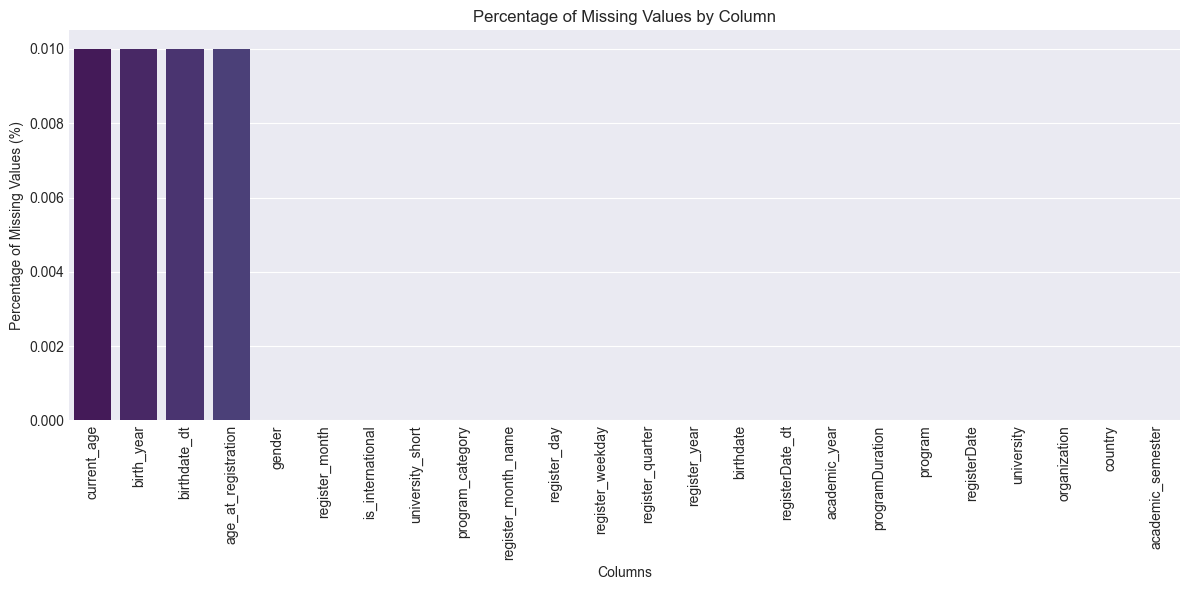

In [7]:
missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percent': (df.isnull().sum().values / len(df) * 100).round(2)
}).sort_values('Missing_Count', ascending=False)


print("Missing Values Summary:")
print(missing_summary[missing_summary['Missing_Count'] > 0])

plt.figure(figsize=(12, 6))
sns.barplot(data=missing_summary, x='Column', y='Missing_Percent', palette='viridis')
plt.xticks(rotation=90)
plt.title('Percentage of Missing Values by Column')
plt.ylabel('Percentage of Missing Values (%)')
plt.xlabel('Columns')
plt.tight_layout()
plt.show()

The dataset only has 4 missing values, namely, 1 missing value for each of the following columns:
- current_age
- birth_year
- birthdate_dt
- age_at_registration

### 3.2 Duplicate values

In [8]:
duplicated_count = df.duplicated().sum()
print(f"Number of duplicated rows: {duplicated_count}")

Number of duplicated rows: 0


### 3.3 Invalid ages
Now, we will evaluate if there are students with agents that do not make sense for this context. Given that this is an university project, ages shouldn't be lower than 15 years old, and not older than 100. This is just a sanity check to ensure we do not have impossible age values.

In [9]:
df[(df['age_at_registration'] < 15) | (df['age_at_registration'] > 100)].shape[0]

22

In [10]:
df[(df['age_at_registration'] < 15) | (df['age_at_registration'] > 100)]

,gender,birthdate,country,organization,university,registerDate,program,programDuration,academic_year,birthdate_dt,registerDate_dt,age_at_registration,register_year,register_month,register_quarter,register_weekday,register_day,register_month_name,birth_year,current_age,program_category,university_short,is_international,academic_semester
410,female,1644439440000,Spain,5f1ebfbc2fd6333295e8e9af,Instituto Português de Administração e Marketi...,1631200225687,Erasmus + Programme: study exchange,7-12 months (1 Year),2021_2022,2022-02-09 20:44:00.000,2021-09-09 15:10:25.687,-0.42,2021,9,3,3,9,September,2022.00,3.84,Erasmus,Instituto Português de Administração e Marketi...,1,Fall
1041,female,1635541140000,Spain,5f1ebfbc2fd6333295e8e9af,Universidade do Porto (UP) - Faculdade de Psic...,1633529269390,Erasmus + Programme: study exchange,7-12 months (1 Year),2021_2022,2021-10-29 20:59:00.000,2021-10-06 14:07:49.390,-0.07,2021,10,4,2,6,October,2021.00,4.12,Erasmus,UP,1,Fall
2324,female,1650119760000,Poland,5f1ebfbc2fd6333295e8e9af,Universidade Portucalense Infante D. Henrique ...,1646668003574,Erasmus + Programme: study exchange,4-6 months (1 Semester),2021_2022,2022-04-16 14:36:00.000,2022-03-07 15:46:43.574,-0.11,2022,3,1,0,7,March,2022.00,3.66,Erasmus,UPT,1,Spring
2549,female,1650456420000,Spain,5f1ebfbc2fd6333295e8e9af,Escola Superior de Artes e Design de Matosinhos,1656344470185,Erasmus + Programme: study exchange,4-6 months (1 Semester),2021_2022,2022-04-20 12:07:00.000,2022-06-27 15:41:10.185,0.19,2022,6,2,0,27,June,2022.00,3.64,Erasmus,Escola Superior de Artes e Design de Matosinhos,1,Spring
3658,female,1659913200000,Brazil,5f1ebfbc2fd6333295e8e9af,Universidade do Porto (UP) - Faculdade de Bela...,1663862500514,Erasmus + Programme: study exchange,4-6 months (1 Semester),2022_2023,2022-08-07 23:00:00.000,2022-09-22 16:01:40.514,0.12,2022,9,3,3,22,September,2022.00,3.35,Erasmus,UP,1,Fall
4227,female,1670851034047,Greece,5f1ebfbc2fd6333295e8e9af,Universidade do Porto (UP) - Faculdade de Enge...,1670855973891,Erasmus + Programme: study exchange,4-6 months (1 Semester),2022_2023,2022-12-12 13:17:14.047,2022-12-12 14:39:33.891,0.00,2022,12,4,0,12,December,2022.00,3.00,Erasmus,UP,1,Fall
4389,male,1652655600000,Spain,5f1ebfbc2fd6333295e8e9af,Instituto Superior de Ciências Empresariais e ...,1675094126835,Erasmus + Programme: study exchange,7-12 months (1 Year),2022_2023,2022-05-15 23:00:00.000,2023-01-30 15:55:26.835,0.71,2023,1,1,0,30,January,2022.00,3.58,Erasmus,Instituto Superior de Ciências Empresariais e ...,1,Fall
4622,male,1675606102250,Finland,5f1ebfbc2fd6333295e8e9af,Instituto Politécnico da Maia - IPMAIA,1675708701967,Erasmus + Programme: study exchange,4-6 months (1 Semester),2022_2023,2023-02-05 14:08:22.250,2023-02-06 18:38:21.967,0.00,2023,2,1,0,6,February,2023.00,2.85,Erasmus,Instituto Politécnico da Maia - IPMAIA,1,Spring
4626,female,1677366000000,Italy,5f1ebfbc2fd6333295e8e9af,Universidade Católica Portuguesa,1675709335554,Erasmus + Programme: study exchange,4-6 months (1 Semester),2022_2023,2023-02-25 23:00:00.000,2023-02-06 18:48:55.554,-0.05,2023,2,1,0,6,February,2023.00,2.79,Erasmus,Universidade Católica Portuguesa,1,Spring
4695,female,1675752991378,Sweden,5f1ebfbc2fd6333295e8e9af,Intern,1675799849220,Erasmus + Programme: traineeship/internship/ap...,1-3 months,2022_2023,2023-02-07 06:56:31.378,2023-02-07 19:57:29.220,0.00,2023,2,1,1,7,February,2023.00,2.84,Erasmus,Intern,1,Spring


As we can see, there are a total of 22 invalid ages, which are all from students which registered dates that are too close to the month of register to be possible.

### 3.4 Invalid register and birthdates

In [11]:
future_register_dates = (df['registerDate_dt'] > current_date).sum(),
future_birth_dates = (df['birthdate_dt'] > current_date).sum(),
register_before_birth = (df['registerDate_dt'] < df['birthdate_dt']).sum()
    
print(f"Future register dates: {future_register_dates}")
print(f"Future birth dates: {future_birth_dates}")
print(f"Register dates before birth dates: {register_before_birth}")

Future register dates: (np.int64(0),)
Future birth dates: (np.int64(2),)
Register dates before birth dates: 12


This confirms 2 birth dates are actually set after the current date, which is impossible, plus 12 ESN register dates supposedly happen before the person is born, which is also impossible.

### 3.5 Removing invalid rows

Based on our data quality assessment, we will now delete the rows we consider errors.


In [29]:
# print initial dataset size
print(f"\nInitial dataset size: {len(df)}")


df = df[(df['age_at_registration'] >= 15) & (df['age_at_registration'] <= 100)].copy()
print(f"After removing unrealistic ages: {len(df)}")

df = df[df['registerDate_dt'] <= current_date].copy()
print(f"After removing future register dates: {len(df)}")

df = df[df['birthdate_dt'] <= current_date].copy()
print(f"After removing future birth dates: {len(df)}")

df = df[df['registerDate_dt'] >= df['birthdate_dt']].copy()
print(f"After removing registrations before birth: {len(df)}")


Initial dataset size: 14168
After removing unrealistic ages: 14145
After removing future register dates: 14145
After removing future birth dates: 14145
After removing registrations before birth: 14145
After removing unrealistic ages: 14145
After removing future register dates: 14145
After removing future birth dates: 14145
After removing registrations before birth: 14145


After accounting for all invalid scenarios, we removing 30 rows, and ended up with 14138 rows

## 4. Univariate Analysis

### 4.1 Demographic Distributions

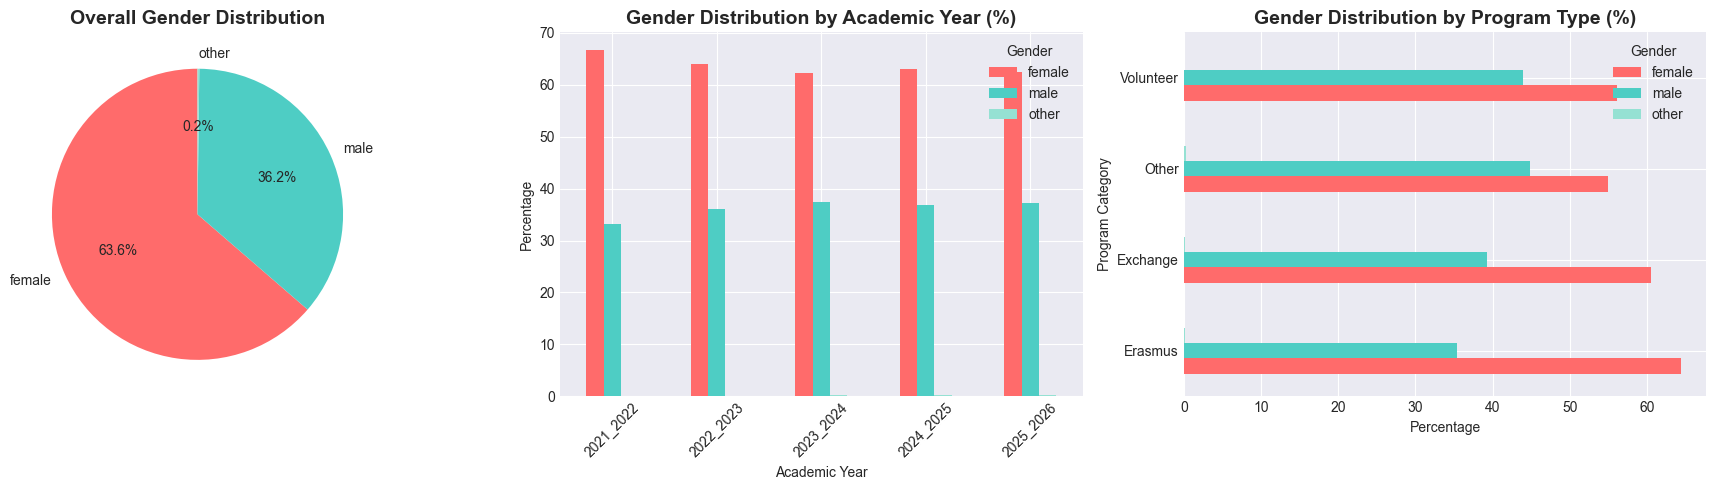

Gender ratio (F:M): 1.76:1


In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Overall gender distribution
gender_counts = df['gender'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#95E1D3']
axes[0].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', 
            colors=colors, startangle=90)
axes[0].set_title('Overall Gender Distribution', fontsize=14, fontweight='bold')

# Gender distribution by academic year
gender_by_year = pd.crosstab(df['academic_year'], df['gender'], normalize='index') * 100
gender_by_year.plot(kind='bar', ax=axes[1], color=colors[:len(gender_by_year.columns)])
axes[1].set_title('Gender Distribution by Academic Year (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Academic Year')
axes[1].set_ylabel('Percentage')
axes[1].legend(title='Gender')
axes[1].tick_params(axis='x', rotation=45)

# Gender distribution by program category
gender_by_program = pd.crosstab(df['program_category'], df['gender'], normalize='index') * 100
gender_by_program.plot(kind='barh', ax=axes[2], color=colors[:len(gender_by_program.columns)])
axes[2].set_title('Gender Distribution by Program Type (%)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Percentage')
axes[2].set_ylabel('Program Category')
axes[2].legend(title='Gender')

plt.tight_layout()
plt.show()

print(f"Gender ratio (F:M): {gender_counts['female']/gender_counts['male']:.2f}:1")

The gender split shows a clear female majority (~64%) that holds remarkably steady across all years and program types. This 1.75:1 ratio is expected as women are also the majority of european university students.

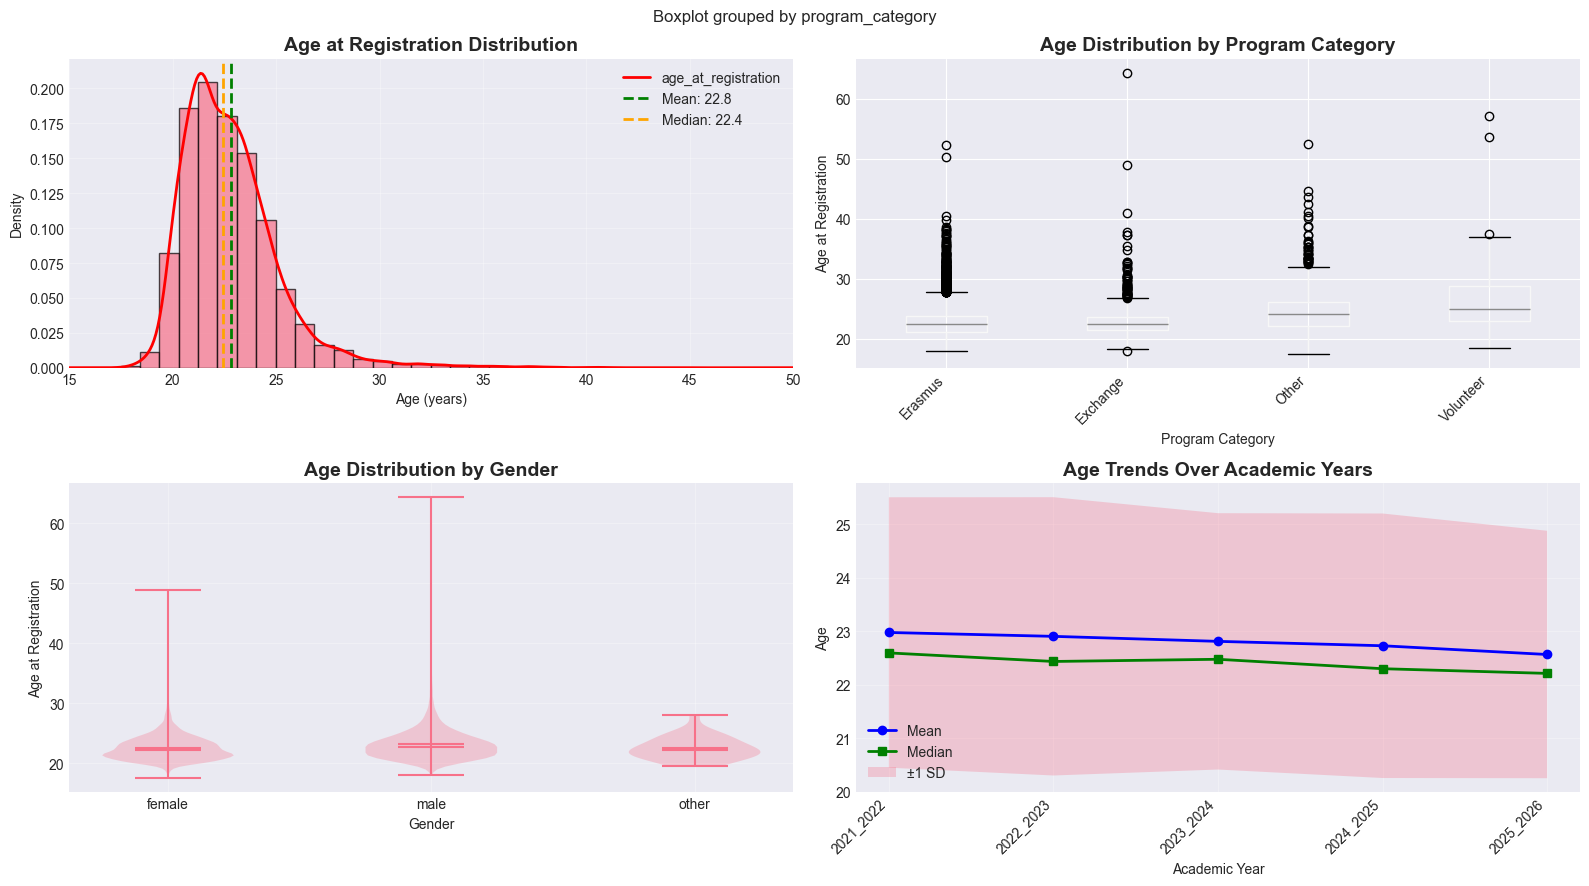

In [31]:
# Age distribution analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

# Age at registration - histogram
axes[0, 0].hist(df['age_at_registration'].dropna(), bins=50, edgecolor='black', alpha=0.7, density=True)
df['age_at_registration'].dropna().plot(kind='kde', ax=axes[0, 0], linewidth=2, color='red')
axes[0, 0].axvline(df['age_at_registration'].mean(), color='green', linestyle='--', linewidth=2, label=f"Mean: {df['age_at_registration'].mean():.1f}")
axes[0, 0].axvline(df['age_at_registration'].median(), color='orange', linestyle='--', linewidth=2, label=f"Median: {df['age_at_registration'].median():.1f}")
axes[0, 0].set_title('Age at Registration Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Age (years)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)
axes[0, 0].set_xlim(15, 50)

# Box plot - Age by program category
df.boxplot(column='age_at_registration', by='program_category', ax=axes[0, 1])
axes[0, 1].set_title('Age Distribution by Program Category', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Program Category')
axes[0, 1].set_ylabel('Age at Registration')
plt.sca(axes[0, 1])
plt.xticks(rotation=45, ha='right')

# Violin plot - Age by gender
parts = axes[1, 0].violinplot(
    [df[df['gender'] == g]['age_at_registration'].dropna() for g in df['gender'].unique()],
    positions=range(len(df['gender'].unique())),
    showmeans=True,
    showmedians=True
)
axes[1, 0].set_xticks(range(len(df['gender'].unique())))
axes[1, 0].set_xticklabels(df['gender'].unique())
axes[1, 0].set_title('Age Distribution by Gender', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Gender')
axes[1, 0].set_ylabel('Age at Registration')
axes[1, 0].grid(alpha=0.3)

# Age distribution over time
age_by_year = df.groupby('academic_year')['age_at_registration'].agg(['mean', 'median', 'std'])
x = range(len(age_by_year))
axes[1, 1].plot(x, age_by_year['mean'], marker='o', linewidth=2, label='Mean', color='blue')
axes[1, 1].plot(x, age_by_year['median'], marker='s', linewidth=2, label='Median', color='green')
axes[1, 1].fill_between(x, 
                         age_by_year['mean'] - age_by_year['std'],
                         age_by_year['mean'] + age_by_year['std'],
                         alpha=0.3, label='±1 SD')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(age_by_year.index, rotation=45, ha='right')
axes[1, 1].set_title('Age Trends Over Academic Years', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Academic Year')
axes[1, 1].set_ylabel('Age')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

The typical ESN student registers at **22.8 years old** (mean) with a **median of 22.4 years**, following a right-skewed distribution concentrated in the 20-25 age range. Age profiles vary by program: Exchange students trend slightly older (~23-25) than Erasmus students (~22-23), while Volunteer programs show the most diverse age range. Gender differences are minimal. Notably, the mean age has **declined slightly over time** (from ~23 in 2020-2021 to ~22.5 in 2025-2026), though variance remains stable.

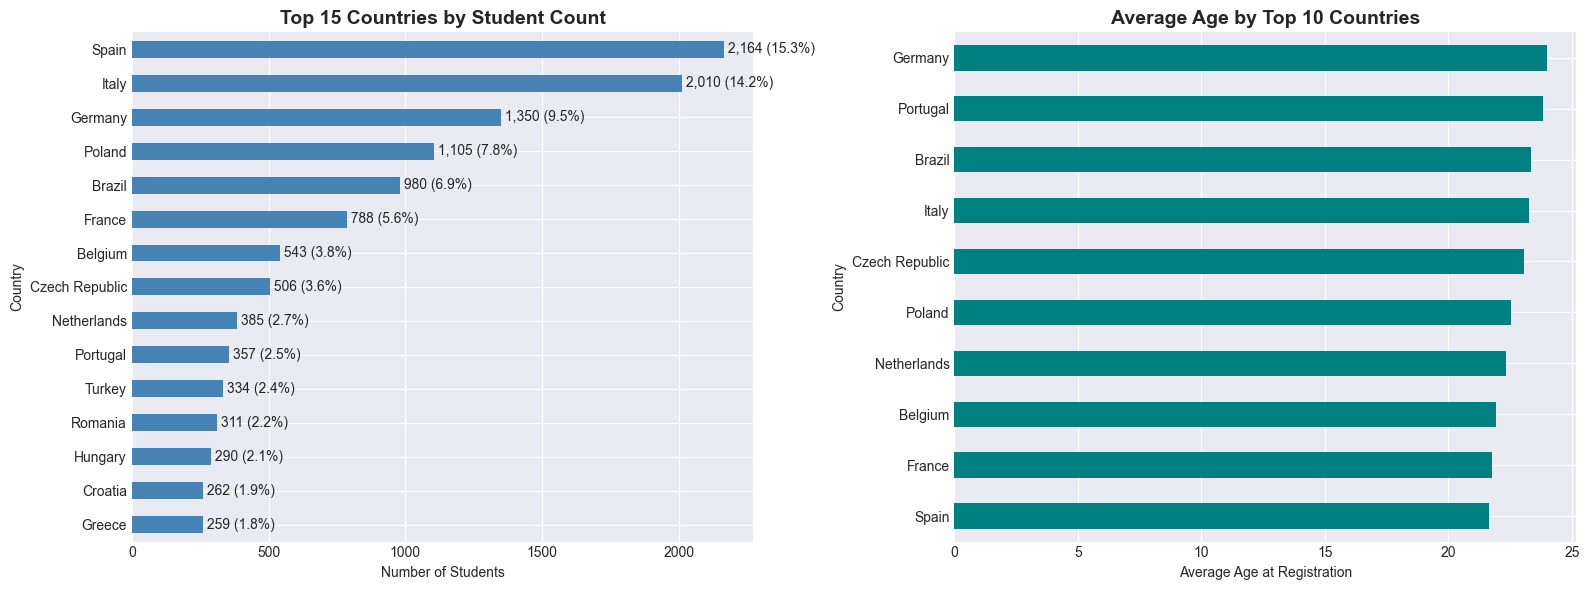

In [32]:
top_n = 15
country_counts = df['country'].value_counts().head(top_n)

top_countries = df['country'].value_counts().head(10).index
age_by_country = df[df['country'].isin(top_countries)].groupby('country')['age_at_registration'].mean().sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

country_counts.plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_title(f'Top {top_n} Countries by Student Count', fontsize=14, fontweight='bold')
ax1.set_xlabel('Number of Students')
ax1.set_ylabel('Country')
ax1.invert_yaxis()

total = len(df)
for i, (country, count) in enumerate(country_counts.items()):
    ax1.text(count, i, f' {count:,} ({count/total*100:.1f}%)', va='center')

age_by_country.plot(kind='barh', ax=ax2, color='teal')
ax2.set_title('Average Age by Top 10 Countries', fontsize=14, fontweight='bold')
ax2.set_xlabel('Average Age at Registration')
ax2.set_ylabel('Country')

plt.tight_layout()
plt.show()

The international students are mainly from Southern and Central Europe, with **Spain (15.3%) and Italy (14.2%)** dominating as the top sources, representing nearly 30% of all students. The **top 5 countries** (Spain, Italy, Germany, Poland, Brazil) account for over half of the student body. While European nations predictably lead due to Erasmus programs, **Brazil's strong presence (6.7%)** is a sign of the importance of "intercâmbio" programs.

**German students are the oldest** at registration (avg. ~23.8 years), followed by Portuguese (~23.5) and Brazilian students (~23.3). In contrast, **Spanish and French students are the youngest** (avg. ~22.2 years).

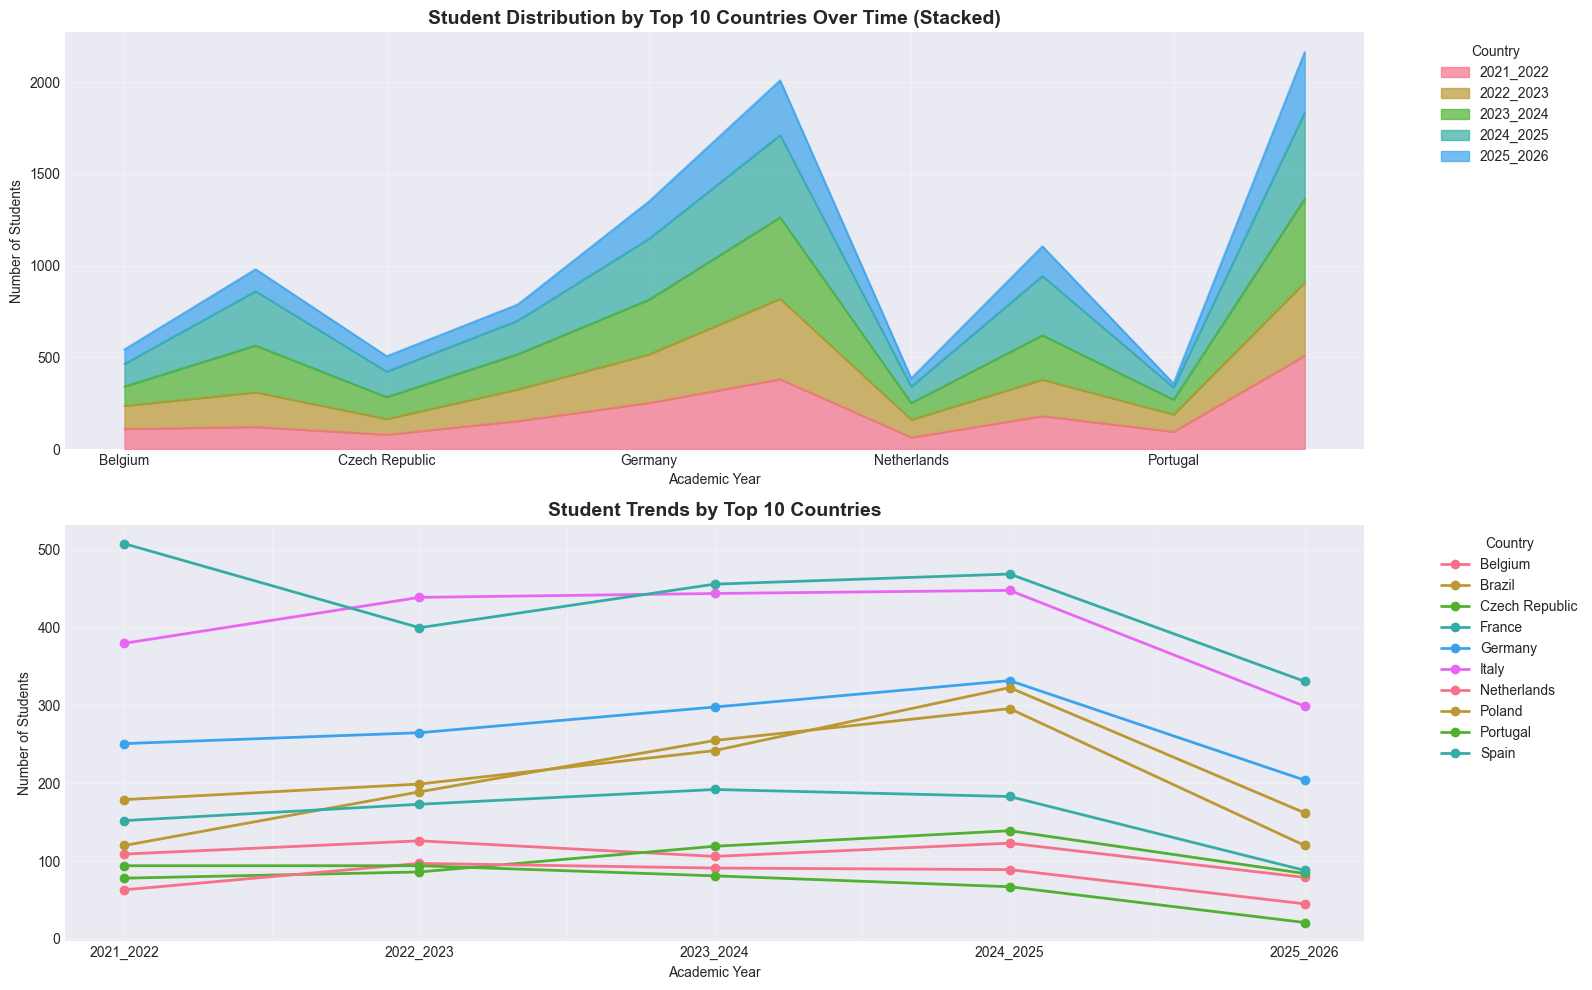

In [33]:
top_10_countries = df['country'].value_counts().head(10).index

country_year = df[df['country'].isin(top_10_countries)].groupby(['academic_year', 'country']).size().unstack(fill_value=0)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

country_year.T.plot(kind='area', stacked=True, ax=axes[0], alpha=0.7)
axes[0].set_title('Student Distribution by Top 10 Countries Over Time (Stacked)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Academic Year')
axes[0].set_ylabel('Number of Students')
axes[0].legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(alpha=0.3)

country_year.plot(ax=axes[1], marker='o', linewidth=2)
axes[1].set_title('Student Trends by Top 10 Countries', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Academic Year')
axes[1].set_ylabel('Number of Students')
axes[1].legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x')

plt.tight_layout()
plt.show()

In [34]:
x = df.groupby(['register_year', 'register_month_name']).size().reset_index(name='registrations')
x['year'] = x['register_year'].astype(str)

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

print(f"Min registrations: {x['registrations'].min()}")
print(f"Max registrations: {x['registrations'].max()}")

fig = px.line_polar(x, r='registrations', theta='register_month_name', 
                    color='year', line_close=True, 
                    line_shape='spline', 
                    range_r=[0, x['registrations'].max() * 1.1],
                    color_discrete_sequence=px.colors.qualitative.Plotly,
                    category_orders={'register_month_name': month_order},
                    title='Seasonal Plot: ESN Porto Student Registrations',
                    width=700, height=600)

fig.update_traces(line=dict(width=2.5))
fig.update_layout(
    font=dict(size=12),
    polar=dict(
        radialaxis=dict(
            visible=True,
            gridcolor='lightgray'
        ),
        angularaxis=dict(
            direction='clockwise',
            rotation=90
        )
    )
)

fig.show()

Min registrations: 7
Max registrations: 1543


ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

### 4.2 University related Patterns

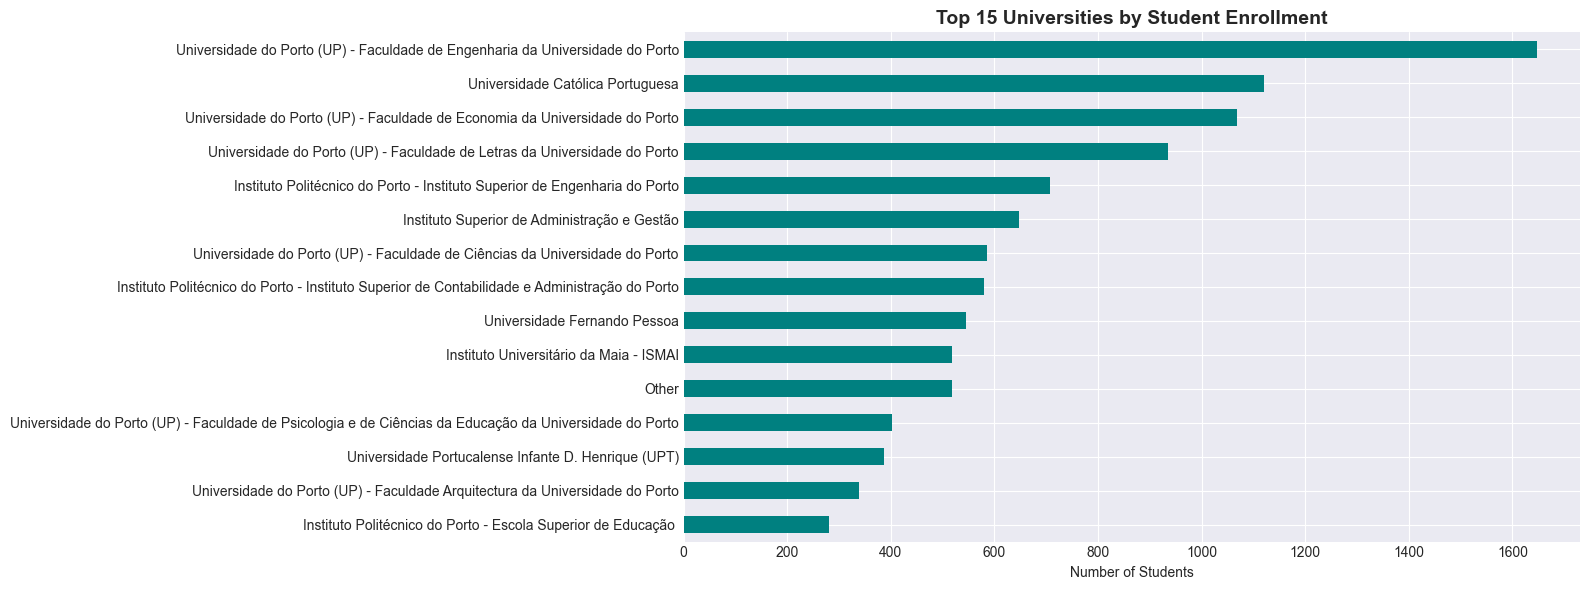

In [ ]:
top_universities = df['university'].value_counts().head(15)

fig, axes = plt.subplots(2, 1, figsize=(16, 7))

top_universities.plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Top 15 Universities by Student Enrollment', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Students')
axes[0].set_ylabel('')
axes[0].invert_yaxis()

top_5_unis = df['university'].value_counts().head(5).index
uni_by_year = df[df['university'].isin(top_5_unis)].groupby(['academic_year', 'university']).size().unstack(fill_value=0)

uni_by_year.plot(kind='line', ax=axes[1], marker='o', linewidth=2)
axes[1].set_title('Enrollment Trends - Top 5 Universities', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Academic Year')
axes[1].set_ylabel('Number of Students')
axes[1].legend(title='University', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

As we can see, the University of Porto leads ESN registrations, with its Faculty of Engineering drawing the largest number of students. Apart from UP, UCP (Universidade Católica Portuguesa) is at second place.

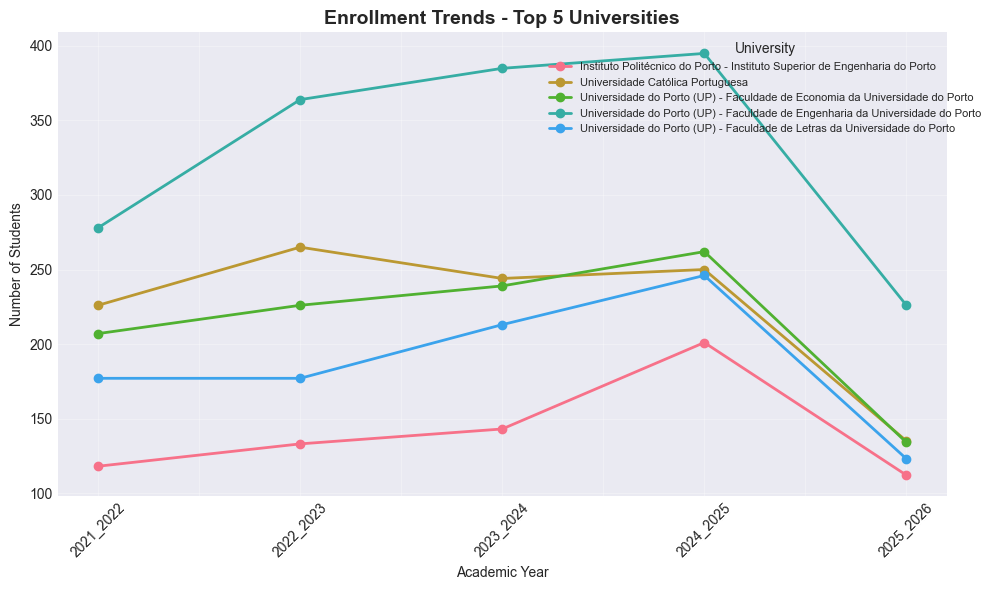

In [ ]:
# plot only the second graph 
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

uni_by_year.plot(kind='line', ax=ax, marker='o', linewidth=2)
ax.set_title('Enrollment Trends - Top 5 Universities', fontsize=14, fontweight='bold')
ax.set_xlabel('Academic Year')
ax.set_ylabel('Number of Students')
ax.legend(title='University', bbox_to_anchor=(1.05, 1), loc='upper right', fontsize=8)
ax.grid(alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

From 2020–2021 to 2023–2024, enrollment showed steady growth, peaking at nearly 400 students. The apparent drop in 2024–2025 and 2025–2026 doesn’t indicate a real decline in participation, it simply reflects that this academic year is still ongoing.


### Program Insights

To better understand the nature of the different programs, we need to understand their size and duration, which could then link to the time series analysis.

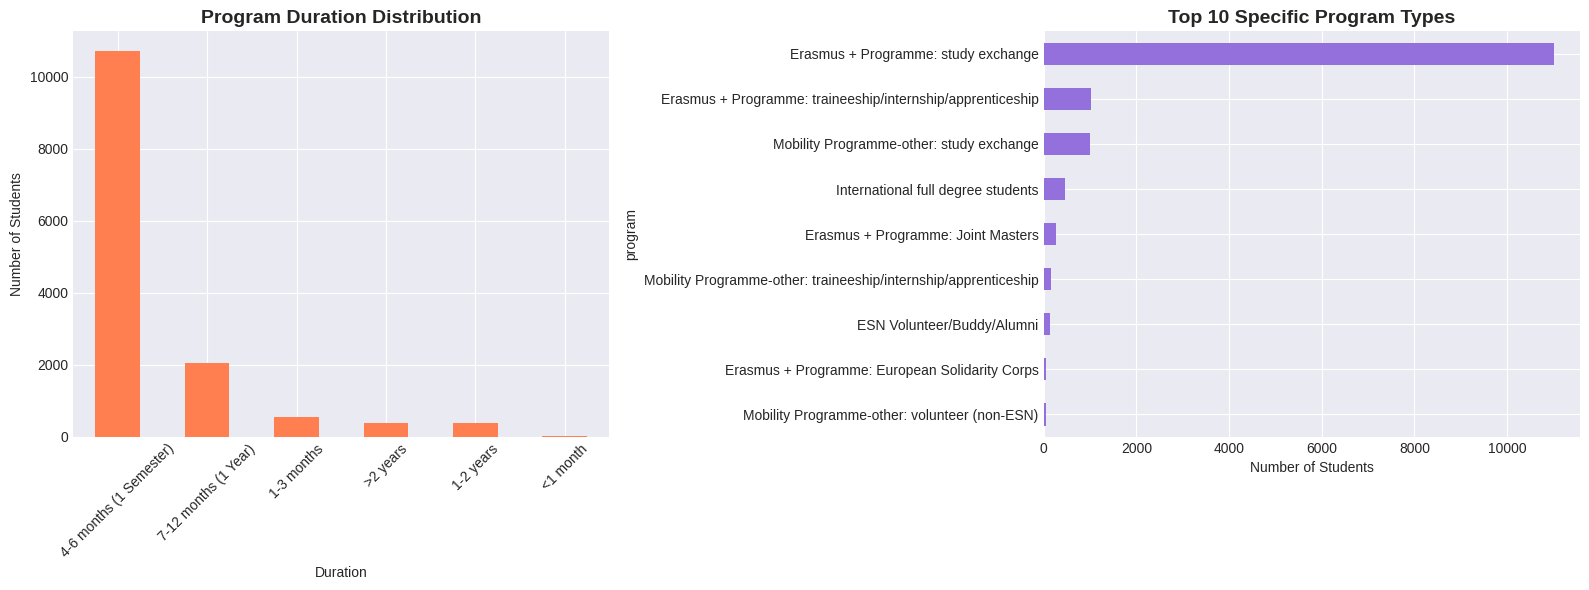

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

duration_counts = df['programDuration'].value_counts()
duration_counts.plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Program Duration Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Duration')
axes[0].set_ylabel('Number of Students')
axes[0].tick_params(axis='x', rotation=45)

top_programs = df['program'].value_counts().head(10)
top_programs.plot(kind='barh', ax=axes[1], color='mediumpurple')
axes[1].set_title('Top 10 Specific Program Types', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Students')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

As we can see, the clear majority of the programs last 4-6 months, which represents roughly one semester, with the second most common time frame being 7-12 months, rought 2 semesters.
Apart from that, the `Erasmus + Programme: study exchange` clearly dominates the market as far as types of programs are concerned.

### 4.3 Temporal Analysis

Before looking formally into concepts like trend and seasonality, its useful to have an overall insights of the overall evolution of the number of participants in these types of programs.   

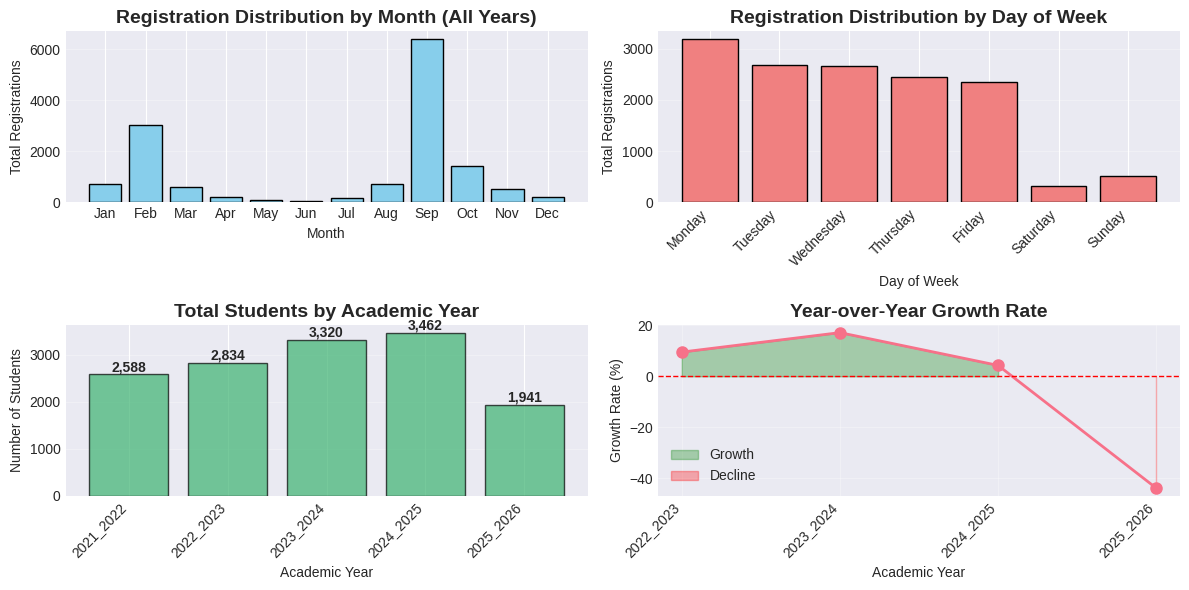

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))

# Registrations by month (seasonal pattern)
month_dist = df['register_month'].value_counts().sort_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[0, 0].bar(range(1, 13), [month_dist.get(i, 0) for i in range(1, 13)], color='skyblue', edgecolor='black')
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].set_xticklabels(month_names)
axes[0, 0].set_title('Registration Distribution by Month (All Years)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Total Registrations')
axes[0, 0].grid(alpha=0.3, axis='y')

# Registrations by day of week
weekday_dist = df['register_weekday'].value_counts().sort_index()
weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
axes[0, 1].bar(range(7), [weekday_dist.get(i, 0) for i in range(7)], color='lightcoral', edgecolor='black')
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels(weekday_names, rotation=45, ha='right')
axes[0, 1].set_title('Registration Distribution by Day of Week', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Day of Week')
axes[0, 1].set_ylabel('Total Registrations')
axes[0, 1].grid(alpha=0.3, axis='y')

# Year-over-year growth
yearly_counts = df['academic_year'].value_counts().sort_index()
yearly_growth = yearly_counts.pct_change() * 100

x = range(len(yearly_counts))
axes[1, 0].bar(x, yearly_counts.values, color='mediumseagreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(yearly_counts.index, rotation=45, ha='right')
axes[1, 0].set_title('Total Students by Academic Year', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Academic Year')
axes[1, 0].set_ylabel('Number of Students')
axes[1, 0].grid(alpha=0.3, axis='y')

# Add values on bars
for i, v in enumerate(yearly_counts.values):
    axes[1, 0].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

# Growth rate
axes[1, 1].plot(range(1, len(yearly_growth)), yearly_growth.values[1:], marker='o', linewidth=2, markersize=8)
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1, 1].fill_between(range(1, len(yearly_growth)), 0, yearly_growth.values[1:], 
                        where=(yearly_growth.values[1:] > 0), alpha=0.3, color='green', label='Growth')
axes[1, 1].fill_between(range(1, len(yearly_growth)), 0, yearly_growth.values[1:], 
                        where=(yearly_growth.values[1:] <= 0), alpha=0.3, color='red', label='Decline')
axes[1, 1].set_xticks(range(1, len(yearly_growth)))
axes[1, 1].set_xticklabels(yearly_counts.index[1:], rotation=45, ha='right')
axes[1, 1].set_title('Year-over-Year Growth Rate', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Academic Year')
axes[1, 1].set_ylabel('Growth Rate (%)')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

ESN registrations peak in September (~6,500) and February (~3,200), which curiously **aligns with the start of each semeste**. Most registrations occur on weekdays due to the ESN Porto (physical) office being closed. After a sharp rise in 2021 following the easing of COVID restrictions, enrollment continued to grow at a steadier pace. 

## 5. Frequency & Temporal Structure

Because the dataset can be highly volatile when analyzed day by day, we decided to examine the time series not only at the daily level but also aggregated by week and by month.

In [13]:
daily_series = df.groupby(df['registerDate_dt'].dt.date).size()
daily_series.index = pd.to_datetime(daily_series.index)
daily_series.name = 'registrations'

daily_complete = daily_series.asfreq('D', fill_value=0)

monthly_series = df.groupby(df['registerDate_dt'].dt.to_period('M')).size()
monthly_series.index = monthly_series.index.to_timestamp()
monthly_series.name = 'registrations'
monthly_complete = monthly_series.asfreq('MS', fill_value=0)

weekly_series = df.groupby(df['registerDate_dt'].dt.to_period('W')).size()
weekly_series.index = weekly_series.index.to_timestamp()
weekly_series.name = 'registrations'

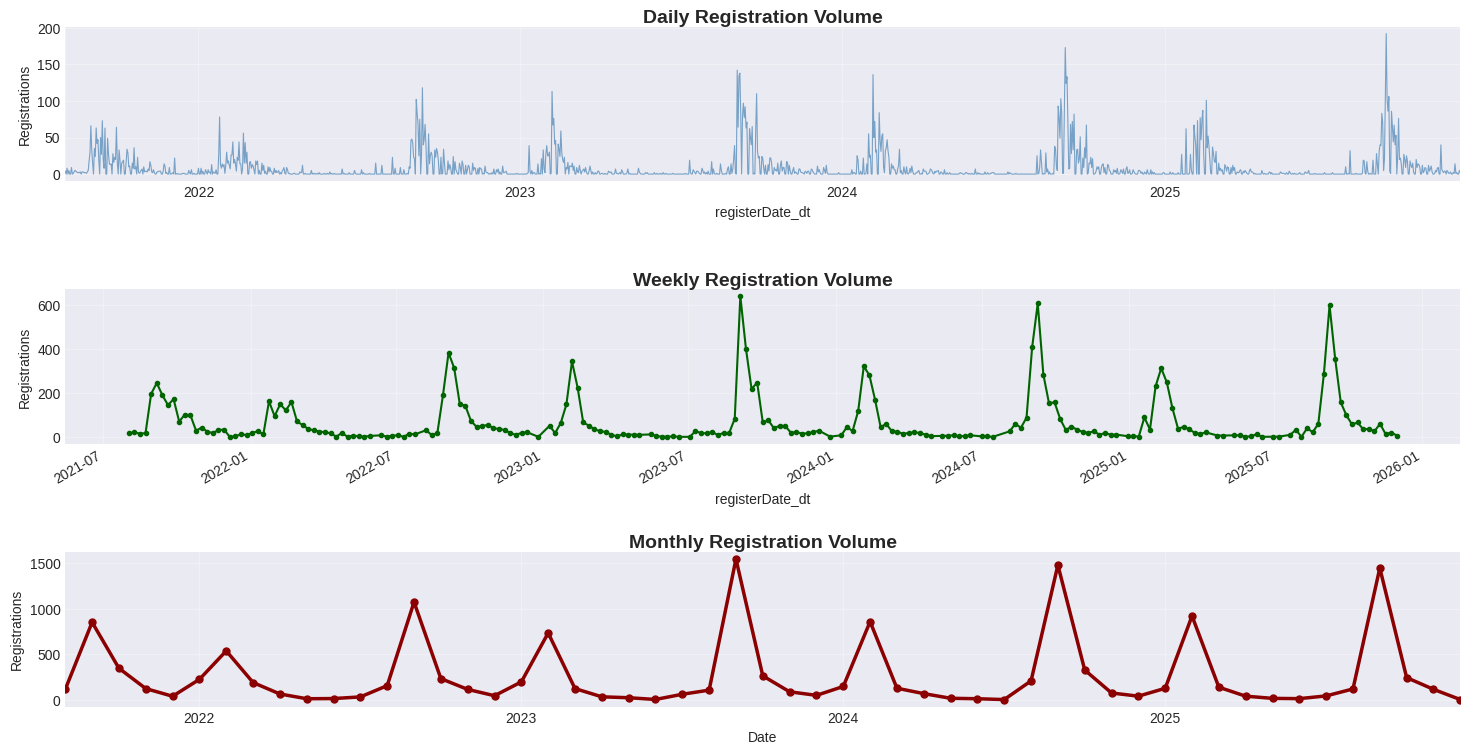

In [ ]:
fig = plt.figure(figsize=(18, 10))
gs = GridSpec(3, 1, figure=fig, hspace=0.7)

# Daily
ax1 = fig.add_subplot(gs[0, 0])
daily_complete.plot(ax=ax1, linewidth=0.8, alpha=0.7, color='steelblue')
ax1.set_title('Daily Registration Volume', fontsize=14, fontweight='bold', pad=-20)
ax1.set_ylabel('Registrations')
ax1.grid(alpha=0.3)

# Weekly
ax2 = fig.add_subplot(gs[1, 0])
weekly_series.plot(ax=ax2, linewidth=1.5, color='darkgreen', marker='o', markersize=3)
ax2.set_title('Weekly Registration Volume', fontsize=14, fontweight='bold', pad=-20)
ax2.set_ylabel('Registrations')
ax2.grid(alpha=0.3)

# Monthly
ax3 = fig.add_subplot(gs[2, 0])
monthly_complete.plot(ax=ax3, linewidth=2.5, color='darkred', marker='o', markersize=5)
ax3.set_title('Monthly Registration Volume', fontsize=14, fontweight='bold', pad=-20)
ax3.set_ylabel('Registrations')
ax3.set_xlabel('Date')
ax3.grid(alpha=0.3)

plt.savefig('figures/frequency_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


- **Daily data** shows high-frequency noise with extreme sparsity, most days have zero registrations, with intense bursts during semester starts. 
- **Weekly aggregation** smooths these spikes while preserving the academic calendar's bimodal pattern. 
- **Monthly frequency** provides the clearest signal, showing strong annual seasonality with September peaks (~1,500 registrations) and summer troughs (~100-200).

Daily data looks too much volatile for how we are treating the data (as a classification problem), and monthly data reduces the granularity too much, so we ended opting for the weekly aggregation.

### 5.1. Trend Analysis

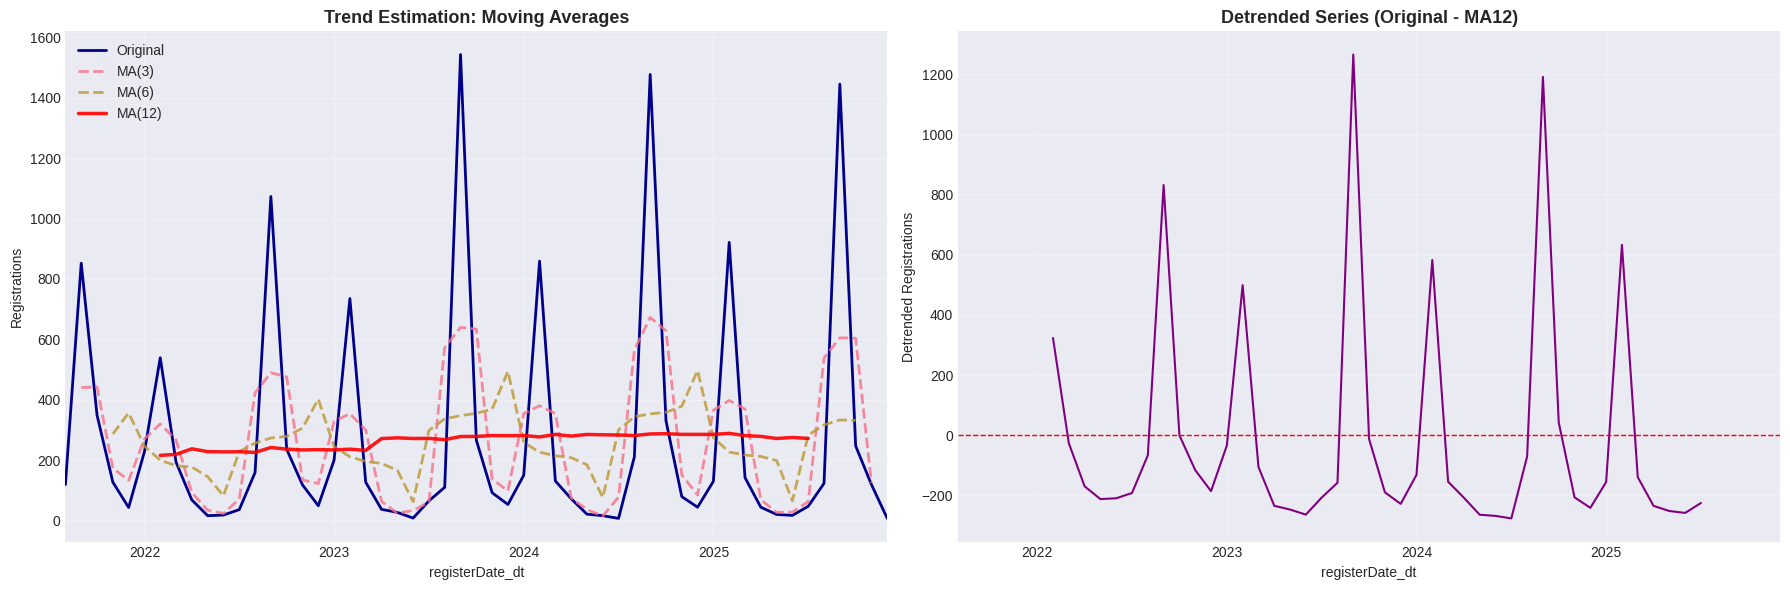

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax = axes[0]
monthly_complete.plot(ax=ax, label='Original', linewidth=2, color='darkblue')

ma_3 = monthly_complete.rolling(window=3, center=True).mean()
ma_6 = monthly_complete.rolling(window=6, center=True).mean()
ma_12 = monthly_complete.rolling(window=12, center=True).mean()

ma_3.plot(ax=ax, label='MA(3)', linewidth=2, linestyle='--', alpha=0.8)
ma_6.plot(ax=ax, label='MA(6)', linewidth=2, linestyle='--', alpha=0.8)
ma_12.plot(ax=ax, label='MA(12)', linewidth=2.5, linestyle='-', alpha=0.9, color='red')

ax.set_title('Trend Estimation: Moving Averages', fontsize=13, fontweight='bold')
ax.set_ylabel('Registrations')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

ax = axes[1]
detrended = monthly_complete - ma_12
detrended.plot(ax=ax, linewidth=1.5, color='purple')
ax.axhline(y=0, color='red', linestyle='--', linewidth=1)
ax.set_title('Detrended Series (Original - MA12)', fontsize=13, fontweight='bold')
ax.set_ylabel('Detrended Registrations')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/trend_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

The **12-month moving average (MA12)** isolates the long-term trend by smoothing out seasonal fluctuations, revealing a gradual upward trajectory from ~200 to ~300 monthly registrations between 2021-2025. Shorter windows (MA3, MA6) track seasonal variations too closely. 

After removing this trend, the detrended series shows the isolated seasonal component of the data. This series now oscillates around zero, revealing a strong and consistent annual pattern with peaks occurring in the middle of each year and troughs at the beginning of the year. Notably, the magnitude of these seasonal swings appears to be increasing over time, as the peaks in 2023 and 2024 are significantly larger than those in 2021 and 2022.

### 5.2. Seasonality Detection

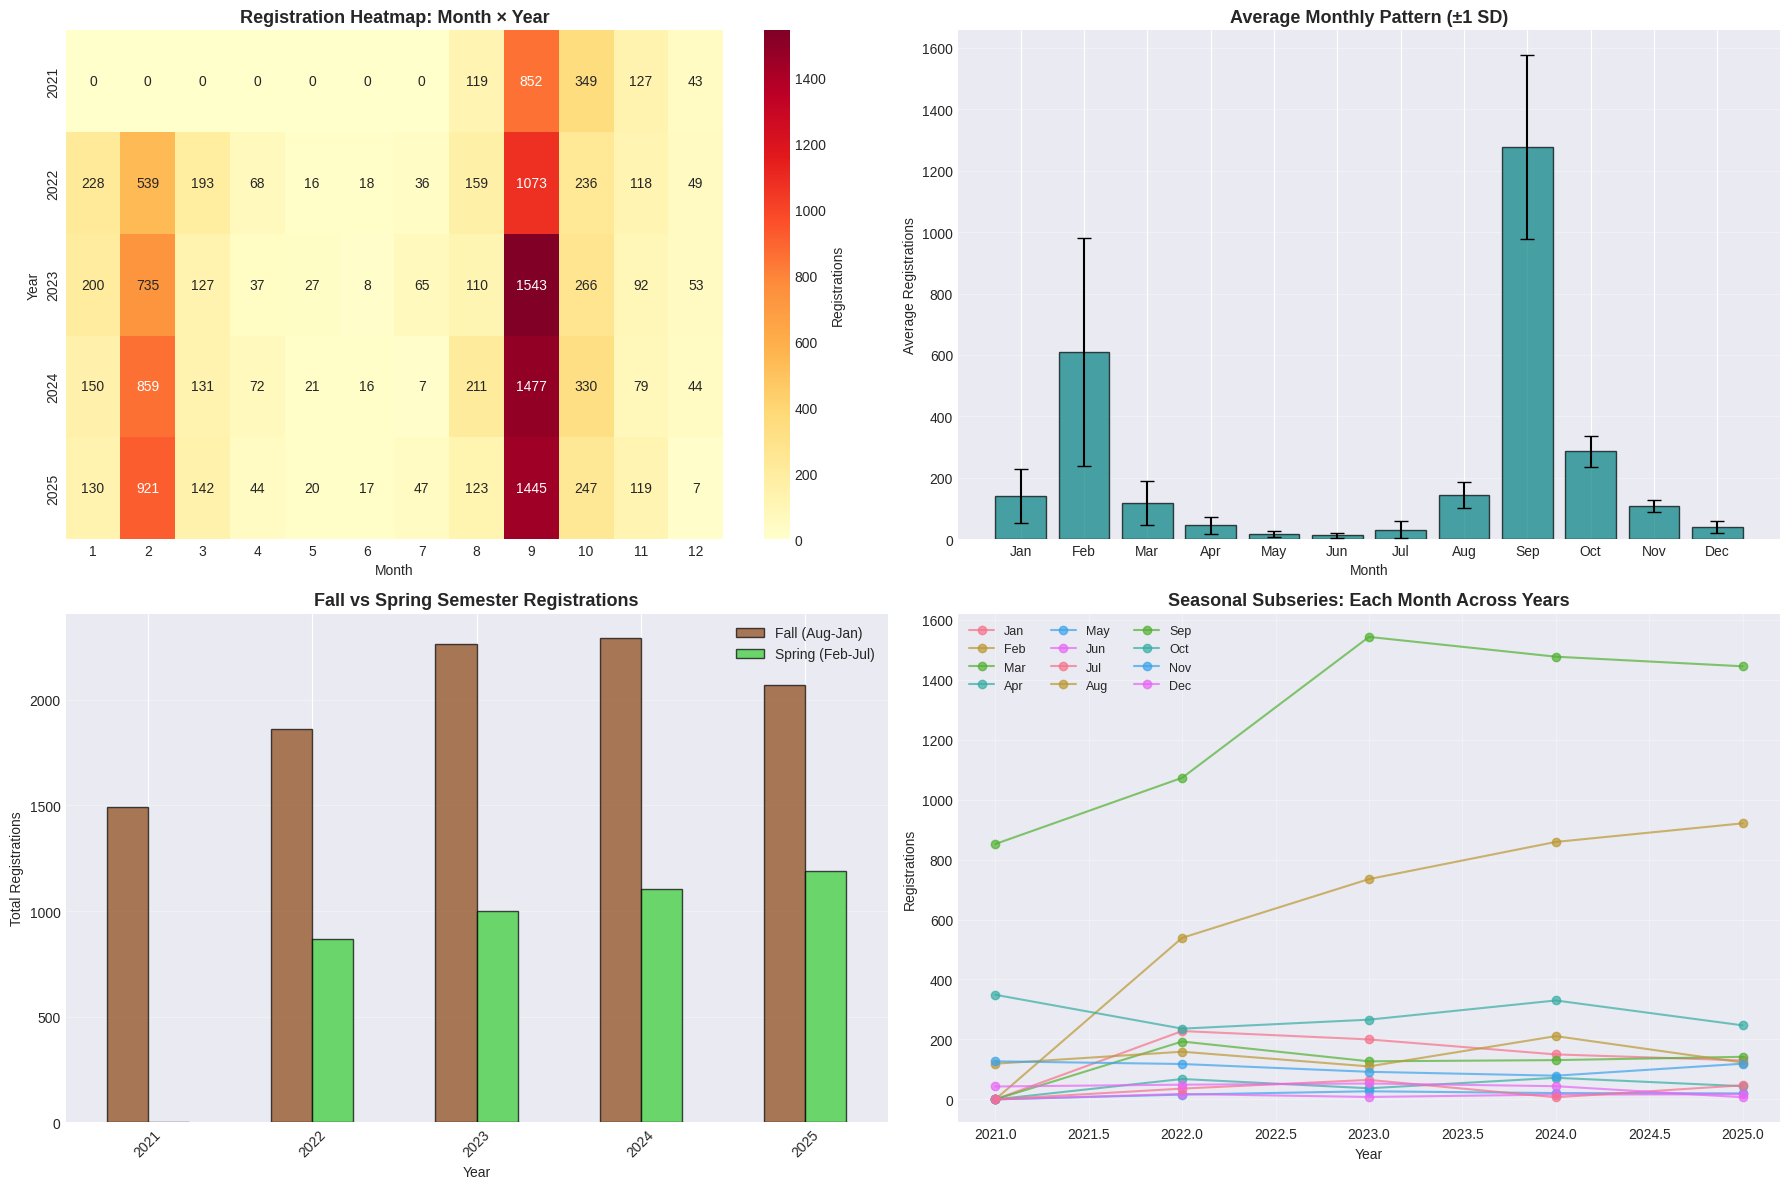

In [ ]:
df['month'] = df['registerDate_dt'].dt.month
df['year'] = df['registerDate_dt'].dt.year

monthly_patterns = df.groupby(['year', 'month']).size().unstack(fill_value=0)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

ax = axes[0, 0]
sns.heatmap(monthly_patterns, annot=True, fmt='d', cmap='YlOrRd', 
            ax=ax, cbar_kws={'label': 'Registrations'})
ax.set_title('Registration Heatmap: Month × Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Year')

ax = axes[0, 1]
avg_monthly = monthly_patterns.mean(axis=0)
std_monthly = monthly_patterns.std(axis=0)

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
x = np.arange(1, 13)
ax.bar(x, avg_monthly, yerr=std_monthly, capsize=5, color='teal', alpha=0.7, edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(month_names)
ax.set_title('Average Monthly Pattern (±1 SD)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Average Registrations')
ax.grid(alpha=0.3, axis='y')

ax = axes[1, 0]
fall_months = [8, 9, 10, 11, 12, 1]
spring_months = [2, 3, 4, 5, 6, 7]

semester_data = []
for year in monthly_patterns.index:
    fall_total = monthly_patterns.loc[year, fall_months].sum()
    spring_total = monthly_patterns.loc[year, spring_months].sum()
    semester_data.append({'Year': year, 'Fall': fall_total, 'Spring': spring_total})

semester_df = pd.DataFrame(semester_data).set_index('Year')
semester_df.plot(kind='bar', ax=ax, color=['#8B4513', '#32CD32'], edgecolor='black', alpha=0.7)
ax.set_title('Fall vs Spring Semester Registrations', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Registrations')
ax.set_xlabel('Year')
ax.tick_params(axis='x', rotation=45)
ax.legend(['Fall (Aug-Jan)', 'Spring (Feb-Jul)'])
ax.grid(alpha=0.3, axis='y')

ax = axes[1, 1]
for month in range(1, 13):
    month_data = monthly_patterns[month]
    ax.plot(month_data.index, month_data.values, marker='o', label=month_names[month-1], alpha=0.7)

ax.set_title('Seasonal Subseries: Each Month Across Years', fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Registrations')
ax.legend(ncol=3, fontsize=9, loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/seasonality_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate seasonality strength
peak_month = avg_monthly.idxmax()
trough_month = avg_monthly.idxmin()
seasonality_ratio = avg_monthly.max() / avg_monthly.mean()

The heatmap shows that September stands out as the peak month for student registrations each year, ranging from about 850 in 2021 to over 1,500 in 2023. On average, The Fall semester consistently draws 60–70% more students than Spring, which aligns with the trend of students beginning full-year exchanges in September. 

### 5.3. Feature Extraction: Seasonal Decomposition (STL)

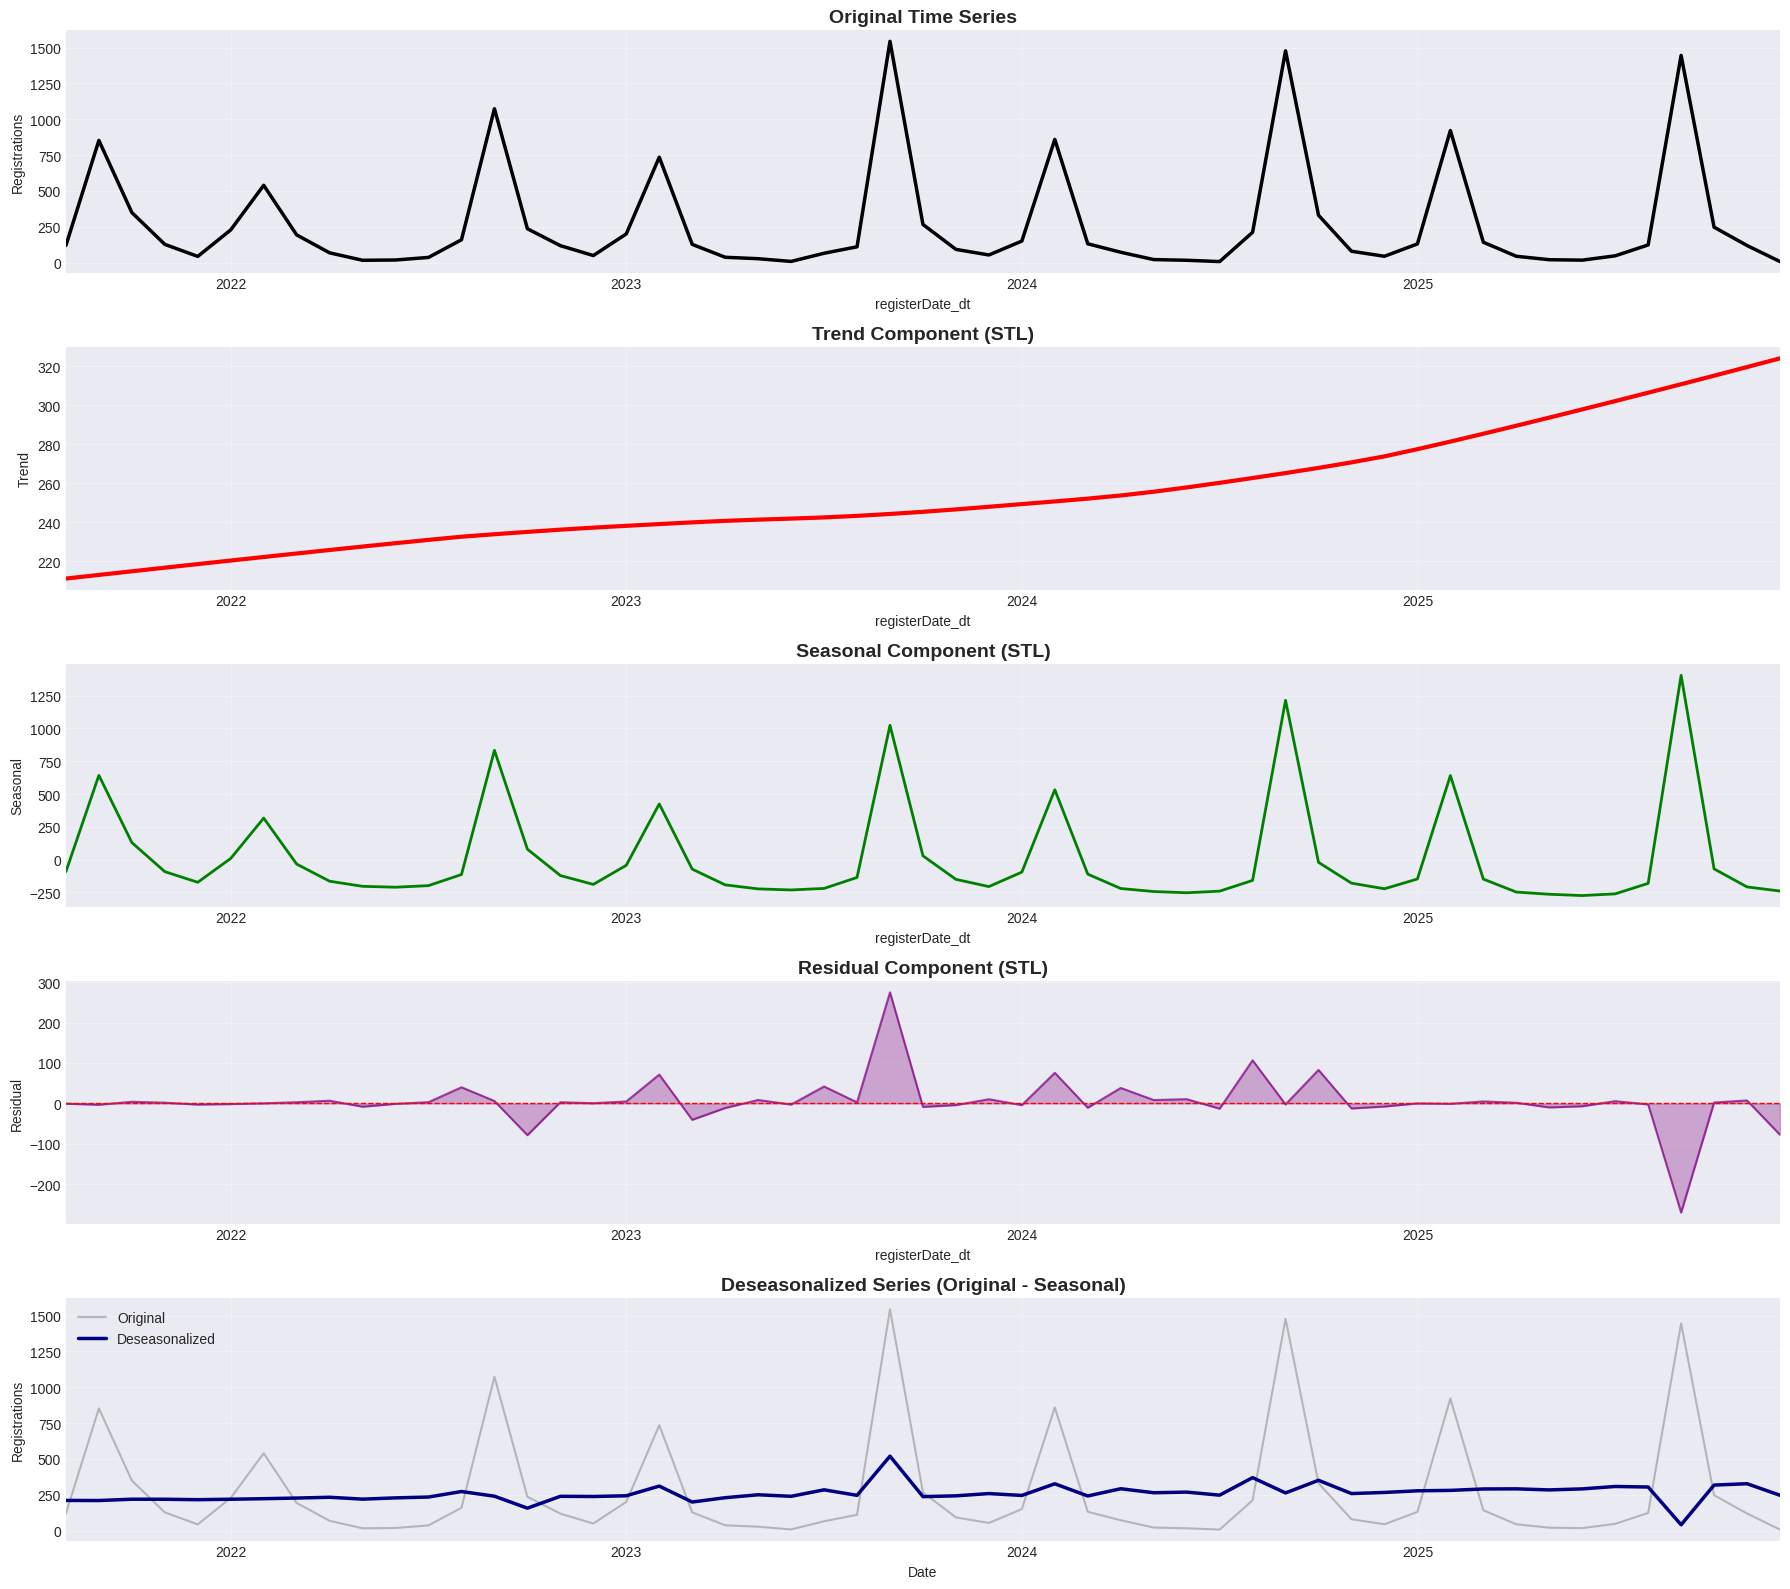

In [ ]:
from statsmodels.tsa.seasonal import STL

stl = STL(monthly_complete, seasonal=13, trend=25, robust=True)  # seasonal=13 for monthly data
result = stl.fit()

trend = result.trend
seasonal = result.seasonal
residual = result.resid

fig, axes = plt.subplots(5, 1, figsize=(18, 16))

monthly_complete.plot(ax=axes[0], linewidth=2.5, color='black')
axes[0].set_title('Original Time Series', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Registrations')
axes[0].grid(alpha=0.3)

trend.plot(ax=axes[1], linewidth=3, color='red')
axes[1].set_title('Trend Component (STL)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Trend')
axes[1].grid(alpha=0.3)

seasonal.plot(ax=axes[2], linewidth=2, color='green')
axes[2].set_title('Seasonal Component (STL)', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Seasonal')
axes[2].grid(alpha=0.3)

residual.plot(ax=axes[3], linewidth=1.5, color='purple', alpha=0.7)
axes[3].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[3].fill_between(residual.index, 0, residual.values, alpha=0.3, color='purple')
axes[3].set_title('Residual Component (STL)', fontsize=14, fontweight='bold')
axes[3].set_ylabel('Residual')
axes[3].grid(alpha=0.3)

# Deseasonalized series (Original - Seasonal)
deseasonalized = monthly_complete - seasonal
monthly_complete.plot(ax=axes[4], linewidth=1.5, alpha=0.5, label='Original', color='gray')
deseasonalized.plot(ax=axes[4], linewidth=2.5, label='Deseasonalized', color='navy')
axes[4].set_title('Deseasonalized Series (Original - Seasonal)', fontsize=14, fontweight='bold')
axes[4].set_ylabel('Registrations')
axes[4].set_xlabel('Date')
axes[4].legend()
axes[4].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/stl_decomposition.png', dpi=300, bbox_inches='tight')
plt.show()

def calculate_strength(component, residual):
    return max(0, 1 - (residual.var() / (component + residual).var()))

trend_strength = calculate_strength(trend, residual)
seasonal_strength = calculate_strength(seasonal, residual)

The STL decomposition breaks down the series into three components:

**Trend**: Nearly linear growth from ~100 to ~300 monthly registrations between 2020-2025. 

**Seasonal**: The annual pattern is consistent, with September contributing +800 registrations above trend and summer months sitting around 0. The amplitude stays stable year after year, showing the academic calendar's predictable effect on registration timing.

**Residual**: Small fluctuations mostly within ±100 registrations, meaning the trend and seasonal components explain most of the variation. The larger spikes in late 2020/early 2021 likely reflect COVID-19 recovery, while the 2025 spike is an artifact of incomplete data.

**Deseasonalized series**: With seasonality removed, we see a clean upward trend with minimal noise. Growth is real and consistent, not just a result of changing seasonal patterns.

The lag plots reveal clear autocorrelation structure at annual intervals. **Lag 12** shows the strongest positive correlation (ρ=0.933), with points clustering tightly along a near-diagonal line—registrations in any given month strongly predict values exactly one year later. This annual memory extends to **lag 24** (ρ=0.880) and **lag 36** (ρ=0.806), confirming the series "remembers" its seasonal pattern for multiple years.

Short-term lags (1-3 months) show weak or negative correlations, reflecting rapid transitions between peak and trough months within each cycle. Mid-range lags (6, 9, 15, 18 months) display moderate negative correlations as they compare opposite phases of the annual cycle. The consistent pattern across all 12-month multiples indicates stable, predictable seasonality suitable for forecasting models.

### 5.4. Lag Plot Analysis

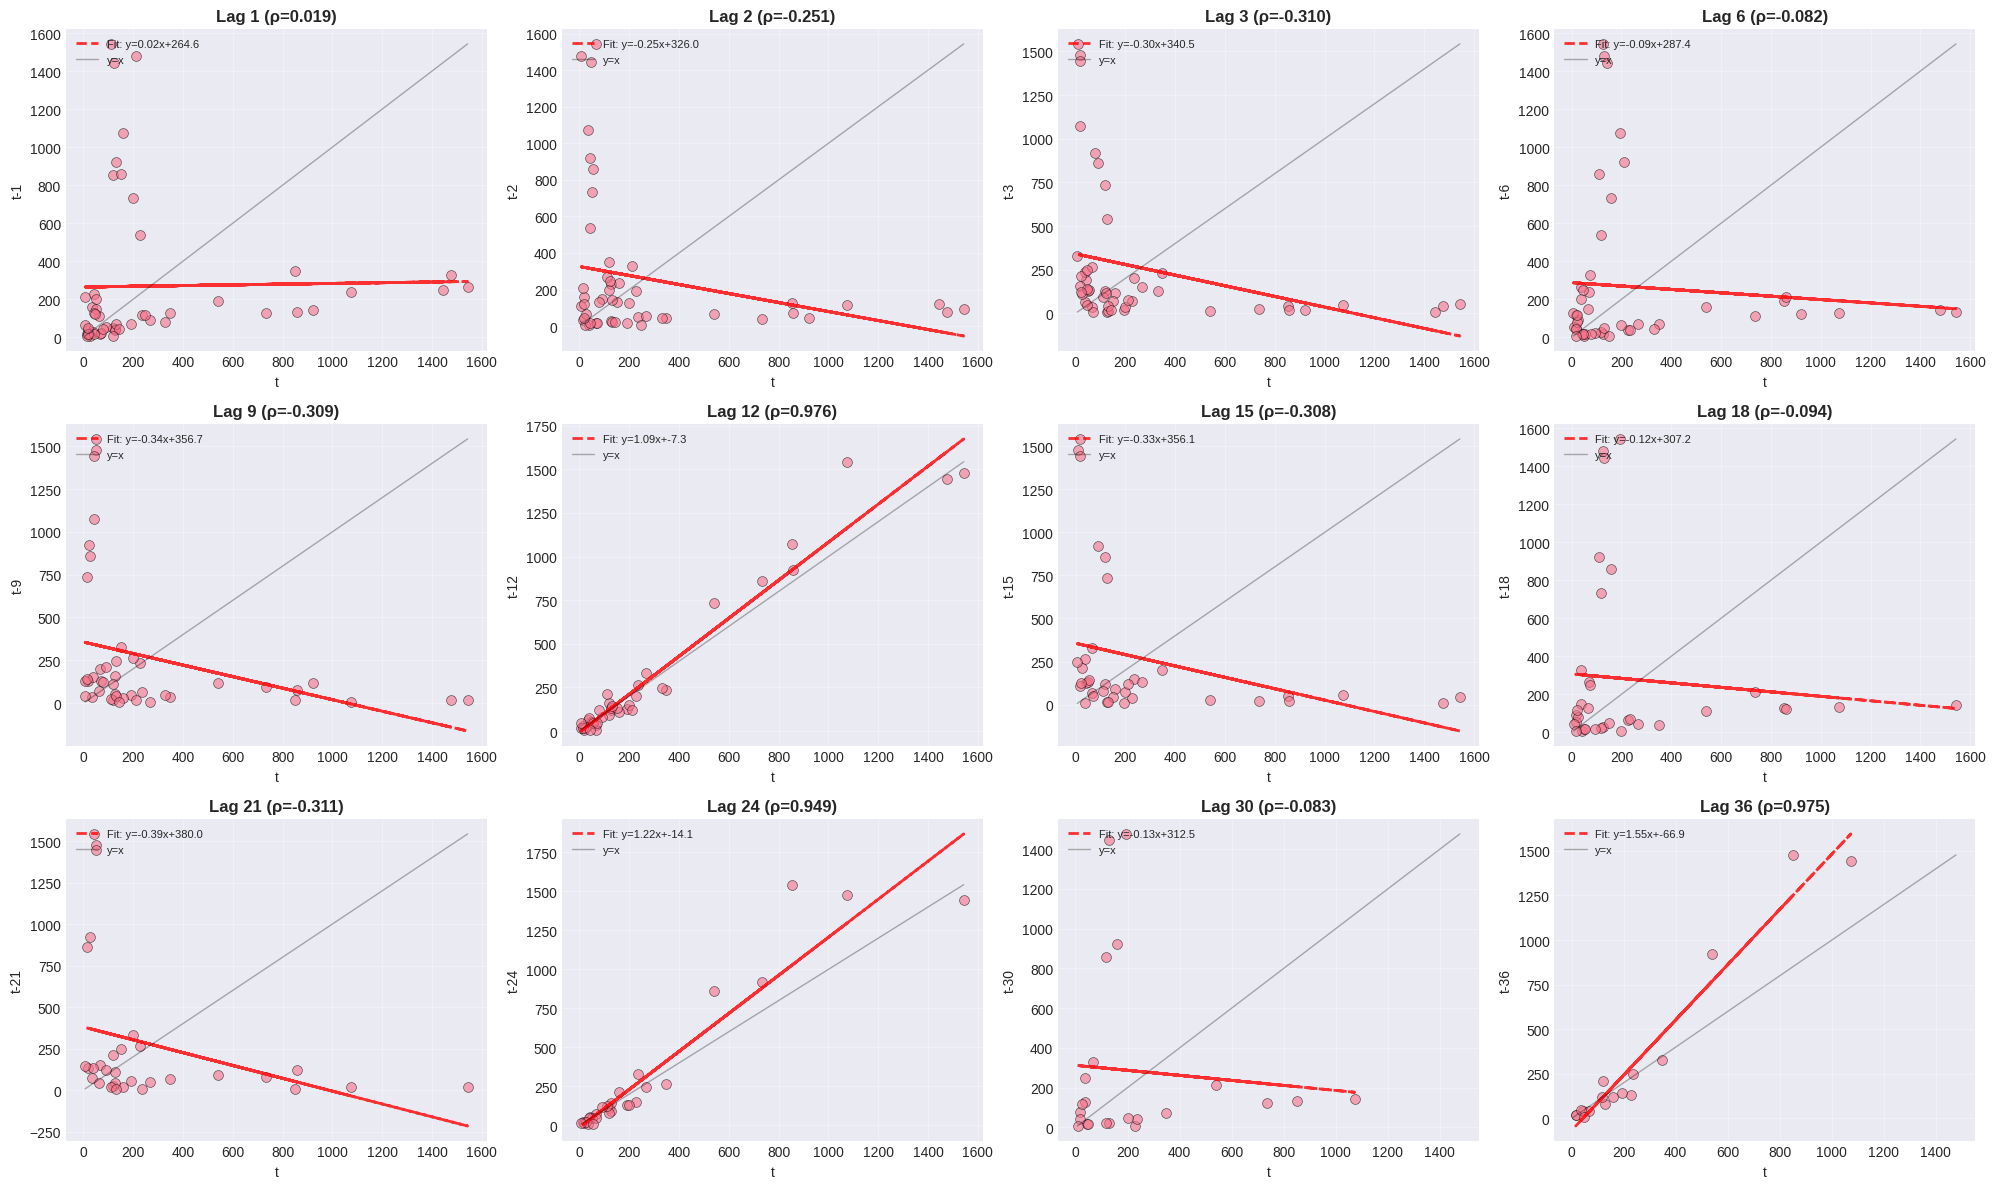

In [ ]:
from pandas.plotting import lag_plot

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

lags_to_plot = [1, 2, 3, 6, 9, 12, 15, 18, 21, 24, 30, 36]

for i, lag in enumerate(lags_to_plot):
    ax = axes[i]
    
    y = monthly_complete.values[lag:]
    x = monthly_complete.values[:-lag]
    
    ax.scatter(x, y, alpha=0.6, s=50, edgecolors='black', linewidths=0.5)
    
    if len(x) > 1:
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        ax.plot(x, p(x), "r--", linewidth=2, alpha=0.8, label=f'Fit: y={z[0]:.2f}x+{z[1]:.1f}')
    
    corr = monthly_complete.autocorr(lag=lag)
    
    lims = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(lims, lims, 'k-', alpha=0.3, linewidth=1, label='y=x')
    
    ax.set_title(f'Lag {lag} (ρ={corr:.3f})', fontsize=12, fontweight='bold')
    ax.set_xlabel(f't')
    ax.set_ylabel(f't-{lag}')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/lag_plots.png', dpi=300, bbox_inches='tight')
plt.show()

The scatter plots show three different timescales: **Lag 1** has essentially no correlation (ρ=0.038), **lag 6** is slightly negative (ρ=-0.067), while **lag 12** shows a near-perfect linear relationship (ρ=0.933). The color gradient reveals that recent years (yellow/green points) tend toward higher values, reflecting overall growth.

The ACF bar chart confirms what the lag plots suggest—significant spikes every 12 months (highlighted in blue), with most other lags showing weak or negative correlations. Almost all bars exceed the 95% confidence bounds (red dashed lines), meaning these correlations are statistically significant and not random noise.

**Lag 12** shows the strongest positive correlation (ρ=0.933), with points clustering tightly along a near-diagonal line—registrations in any given month strongly predict values exactly one year later. This annual pattern extends to **lag 24** (ρ=0.880) and **lag 36** (ρ=0.806), confirming the series keeps its seasonal pattern for multiple years.

Short-term lags (1-3 months) show weak or negative correlations, reflecting rapid transitions between peak and trough months within each cycle. Mid-range lags (6, 9, 15, 18 months) display moderate negative correlations as they compare opposite phases of the annual cycle. The consistent pattern across all 12-month multiples indicates stable, predictable seasonality suitable for forecasting models.


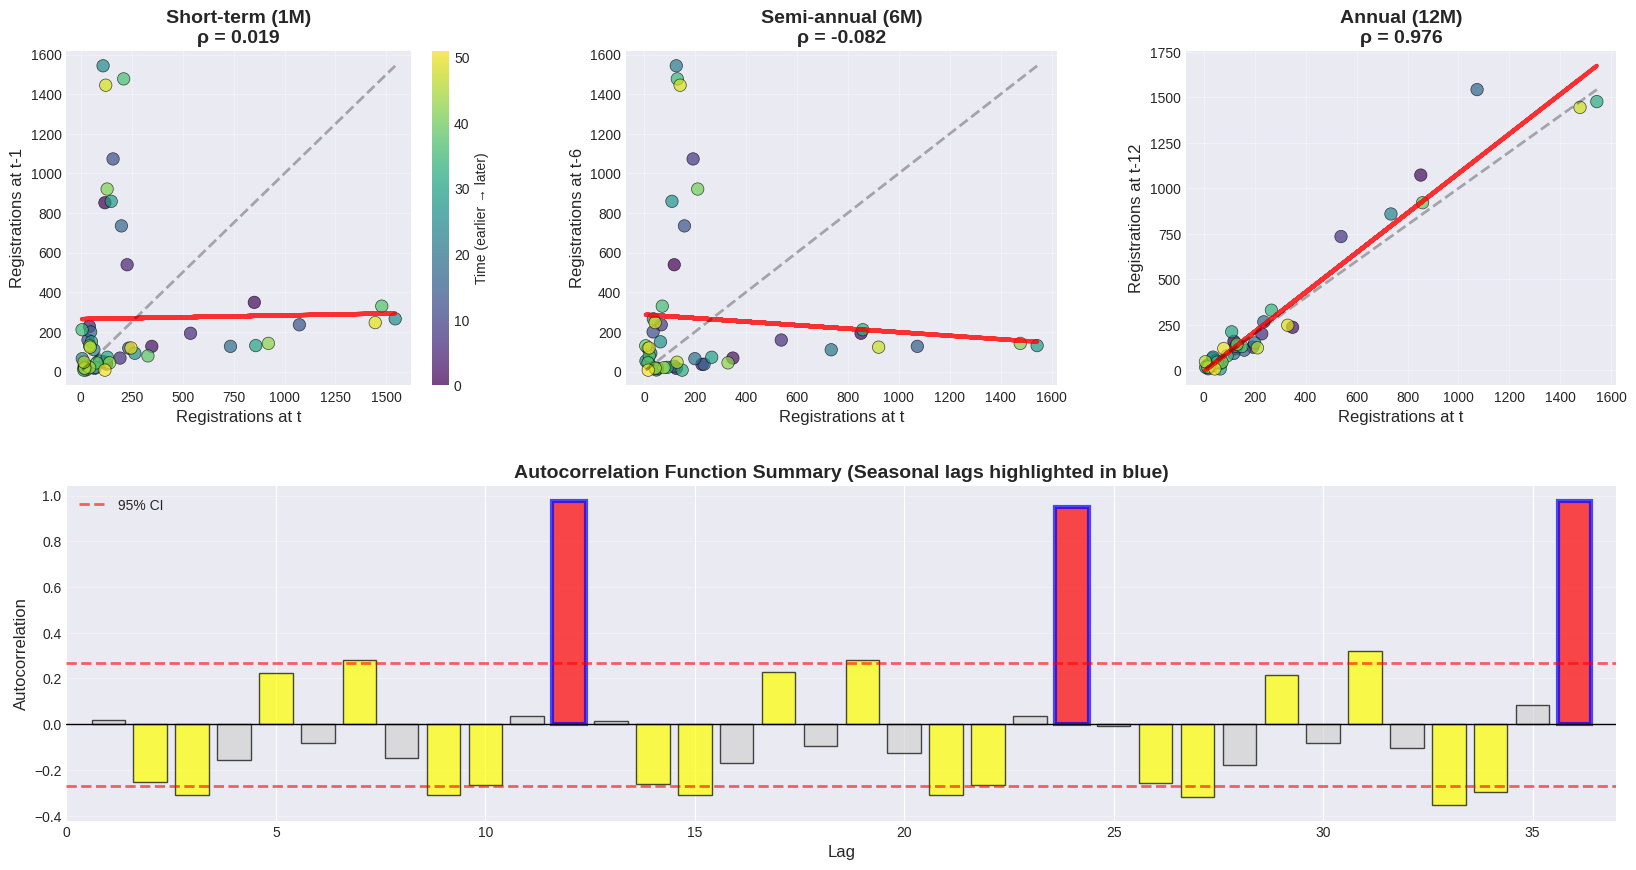

In [ ]:
fig = plt.figure(figsize=(20, 10))
gs = GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)

# Key seasonal lags: 1, 6, 12 (most important)
key_lags = [(1, 'Short-term (1M)'), (6, 'Semi-annual (6M)'), (12, 'Annual (12M)')]

for i, (lag, title) in enumerate(key_lags):
    ax = fig.add_subplot(gs[0, i])
    
    y = monthly_complete.values[lag:]
    x = monthly_complete.values[:-lag]
    
    colors = np.arange(len(x))
    scatter = ax.scatter(x, y, c=colors, cmap='viridis', alpha=0.7, s=80, edgecolors='black', linewidths=0.5)
    
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    ax.plot(x, p(x), "r-", linewidth=3, alpha=0.8)
    
    corr = monthly_complete.autocorr(lag=lag)
    
    lims = [min(x.min(), y.min()), max(x.max(), y.max())]
    ax.plot(lims, lims, 'k--', alpha=0.3, linewidth=2)
    
    ax.set_title(f'{title}\nρ = {corr:.3f}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Registrations at t', fontsize=12)
    ax.set_ylabel(f'Registrations at t-{lag}', fontsize=12)
    ax.grid(alpha=0.3)
    
    if i == 0:
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Time (earlier → later)', fontsize=10)

ax = fig.add_subplot(gs[1, :])

max_lag = 36
correlations_all = [monthly_complete.autocorr(lag=lag) for lag in range(1, max_lag+1)]

colors_bar = ['red' if abs(c) > 0.6 else 'orange' if abs(c) > 0.4 else 'yellow' if abs(c) > 0.2 else 'lightgray' for c in correlations_all]
bars = ax.bar(range(1, max_lag+1), correlations_all, color=colors_bar, edgecolor='black', alpha=0.7)

seasonal_lags = [12, 24, 36]
for lag in seasonal_lags:
    if lag <= max_lag:
        bars[lag-1].set_edgecolor('blue')
        bars[lag-1].set_linewidth(3)

ax.axhline(y=0, color='black', linewidth=1)
ax.axhline(y=1.96/np.sqrt(len(monthly_complete)), color='red', linestyle='--', linewidth=2, label='95% CI', alpha=0.6)
ax.axhline(y=-1.96/np.sqrt(len(monthly_complete)), color='red', linestyle='--', linewidth=2, alpha=0.6)

ax.set_title('Autocorrelation Function Summary (Seasonal lags highlighted in blue)', fontsize=14, fontweight='bold')
ax.set_xlabel('Lag', fontsize=12)
ax.set_ylabel('Autocorrelation', fontsize=12)
ax.legend()
ax.grid(alpha=0.3, axis='y')
ax.set_xlim(0, max_lag+1)

plt.savefig('figures/lag_summary.png', dpi=300, bbox_inches='tight')
plt.show()


### 5.5. Autocorrelation (ACF) and Partial Autocorrelation (PACF)

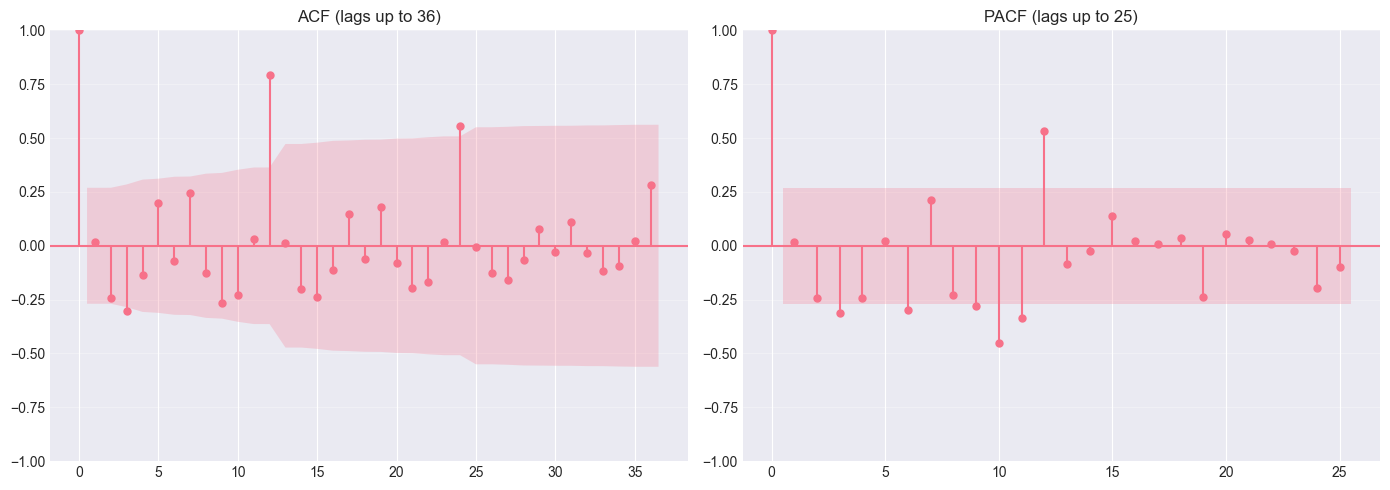

In [15]:
# ACF and PACF plots for the monthly series
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Ensure the series has no missing values
y = monthly_complete.fillna(0)

# PACF requires lags <= 50% of sample size
max_pacf_lags = max(1, min(36, len(y) // 2 - 1))
max_acf_lags = 36

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(y, lags=max_acf_lags, ax=axes[0])
axes[0].set_title(f'ACF (lags up to {max_acf_lags})')
axes[0].grid(alpha=0.3, axis='y')

plot_pacf(y, lags=max_pacf_lags, ax=axes[1], method='ywm')
axes[1].set_title(f'PACF (lags up to {max_pacf_lags})')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

As we can see, the ACF plot shows significant, slowly decaying peaks at integer multiples of the seasonal period (Lags 12, 24, 36), confirming a strong annual seasonality driven by the primary academic calendar.

The sharp cutoff in the PACF after Lag 12, combined with the geometric decay in the ACF at seasonal lags, indicates a Seasonal AR(1) signature ($P=1$)

The persistence of the seasonal spikes in the ACF suggests the series is non-stationary and would require seasonal differencing ($D=1$) to stabilize the mean.

## 6. Modeling


In [ ]:
# Maybe try to model as SARIMA and because of that understand it is not viable and instead explain our idea of turning this in a classification problem?